In [1]:
import shutil
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pyblock.blocking

from jaqmc.utils.config import ConfigManager

In [3]:
digest = dict(np.load("/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_3.78_2_h_3_supcell_i_0h_1s_j_3h_1s_rdm_eval_old/evaluation_digest.npz"))

print("Digest contents:")
for key, value in sorted(digest.items()):
    if value.ndim == 0:
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: shape={value.shape}")

SiSj = 0.25*(digest['gamma2_uu_ijij'] + digest['gamma2_dd_ijij'] - digest['gamma2_ud_ijij'] - digest['gamma2_ud_jiji'])
print(f"<S_i S_j>: {SiSj}")
#j=3

Digest contents:
  energy:kinetic: 2.630739-0.000089j
  energy:kinetic_var: 5.398290-0.001225j
  energy:potential: -5.716905
  energy:potential_var: 5.395854
  gamma1_down_ii: 0.124922+0.000013j
  gamma1_up_ii: 0.123520+0.000011j
  gamma2_dd_ijij: 0.011476+0.000007j
  gamma2_ud_ijij: 0.019895+0.000018j
  gamma2_ud_jiji: 0.019179-0.000001j
  gamma2_uu_ijij: 0.012597-0.000023j
  total_energy: -3.086166-0.000089j
  total_energy_real: -3.086166
  total_energy_real_var: 0.001344
<S_i S_j>: (-0.003750187810510397-8.214944500650745e-06j)


In [ ]:
#Energy variance looks too big...? Probably need to run more iterations?

In [2]:
digest = dict(np.load("/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_rdm_i0j1_eval/evaluation_digest.npz"))

print("Digest contents:")
for key, value in sorted(digest.items()):
    if value.ndim == 0:
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: shape={value.shape}")

SiSj = 0.25*(digest['gamma2_uu_ijij'] + digest['gamma2_dd_ijij'] - digest['gamma2_ud_ijij'] - digest['gamma2_ud_jiji'])
print(f"<S_i S_j>: {SiSj}")

Digest contents:
  energy:kinetic: 2.618067+0.000050j
  energy:kinetic_var: 5.342924-0.001221j
  energy:potential: -5.704156
  energy:potential_var: 5.341677
  gamma1_down_ii: 0.118549-0.000011j
  gamma1_up_ii: 0.127103+0.000025j
  gamma2_dd_ijij: 0.005207+0.000003j
  gamma2_ud_ijij: 0.021905-0.000003j
  gamma2_ud_jiji: 0.022341+0.000018j
  gamma2_uu_ijij: 0.005145-0.000006j
  total_energy: -3.086089+0.000050j
  total_energy_real: -3.086089
  total_energy_real_var: 0.001347
<S_i S_j>: (-0.008473464287817478-4.593907760863658e-06j)


Extracting <S_i S_j> values...

j = 1: <S_i S_j> = -0.008473-0.000005j
j = 2: <S_i S_j> = 0.002300-0.000005j
j = 3: <S_i S_j> = -0.003073-0.000012j
j = 4: <S_i S_j> = 0.003477-0.000001j
j = 5: <S_i S_j> = -0.007076-0.000002j

Shape check -> x: (7,), y: (7,)
Plot saved as 'SiSj_correlation.png'


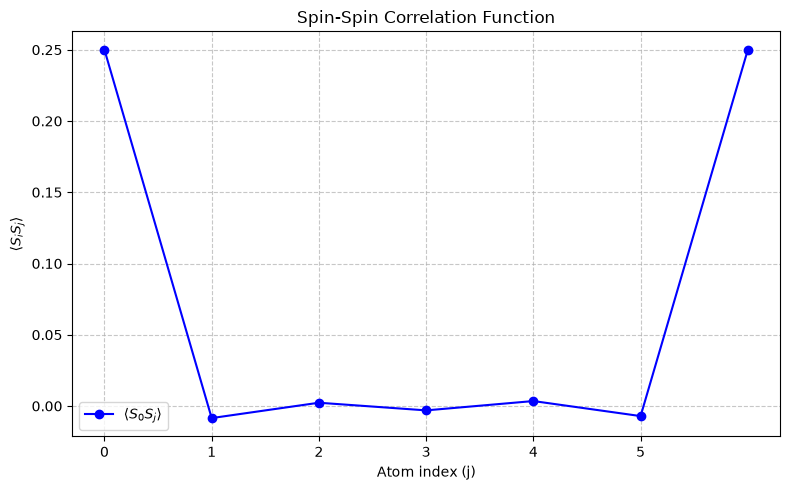

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Base directory where the run folders are stored
base_dir = "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs"
j_values_run = np.arange(1, 6)  

# 1. Extract values into a completely new Python list
SiSj_list = []

print("Extracting <S_i S_j> values...\n")

for j in j_values_run:
    folder_name = f"h_chain_rdm_i0j{j}_eval"
    file_path = os.path.join(base_dir, folder_name, "evaluation_digest.npz")
    
    try:
        digest = dict(np.load(file_path))
        SiSj = 0.25 * (
            digest['gamma2_uu_ijij'] + 
            digest['gamma2_dd_ijij'] - 
            digest['gamma2_ud_ijij'] - 
            digest['gamma2_ud_jiji']
        )
        if isinstance(SiSj, np.ndarray) and SiSj.ndim == 0:
            SiSj = SiSj.item()
            
        SiSj_list.append(SiSj)
        print(f"j = {j}: <S_i S_j> = {SiSj:.6f}")
        
    except FileNotFoundError:
        print(f"Warning: File not found for j={j} at {file_path}")
        SiSj_list.append(np.nan)

# 2. Safely create the 7-element arrays
# Front: 0.25, Middle: the 5 extracted values, Back: 0.25 -> Total length = 7
SiSj_values = np.array([0.25] + SiSj_list + [0.25])
j_values_plot = np.array([0, 1, 2, 3, 4, 5, 6])

# Verify shapes match before plotting
print(f"\nShape check -> x: {j_values_plot.shape}, y: {SiSj_values.shape}")

# 3. Plotting the results
plt.figure(figsize=(8, 5))

plt.plot(j_values_plot, SiSj_values, marker='o', linestyle='-', color='b', label=r'$\langle S_0 S_j \rangle$')

plt.title('Spin-Spin Correlation Function')
plt.xlabel('Atom index (j)')
plt.ylabel(r'$\langle S_i S_j \rangle$')

plt.xticks(np.arange(0, 6)) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig("SiSj_correlation.png", dpi=300)
print("Plot saved as 'SiSj_correlation.png'")

plt.show()

Plot saved as 'SiSj_correlation.png'


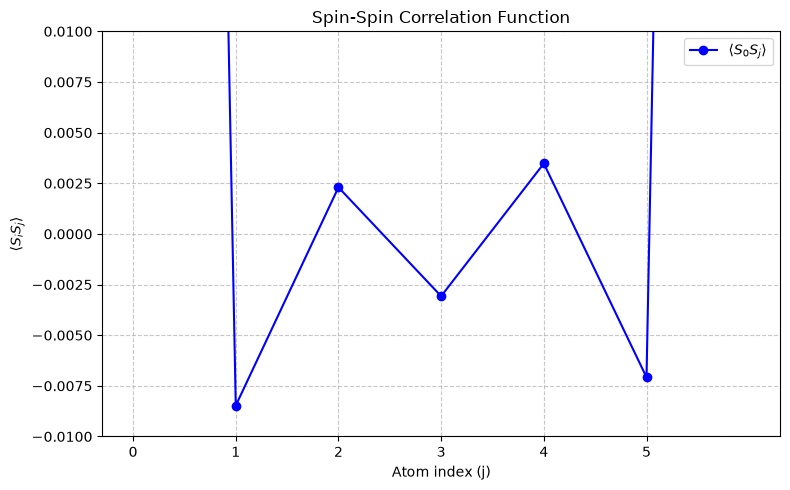

In [18]:
# 3. Plotting the results
plt.figure(figsize=(8, 5))

plt.plot(j_values_plot, SiSj_values, marker='o', linestyle='-', color='b', label=r'$\langle S_0 S_j \rangle$')

# ---------------------------------------------------------
# Set y-axis limits to +/- 0.01
# ---------------------------------------------------------
plt.ylim(-0.01, 0.01)

plt.title('Spin-Spin Correlation Function')
plt.xlabel('Atom index (j)')
plt.ylabel(r'$\langle S_i S_j \rangle$')
plt.xticks(np.arange(0, 6)) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig("SiSj_correlation.png", dpi=300)
print("Plot saved as 'SiSj_correlation.png'")

plt.show()

## With full training iterations

Extracting <S_i S_j> values...

j = 1: <S_i S_j> = -0.007730+0.000001j
j = 2: <S_i S_j> = 0.002368-0.000005j
j = 3: <S_i S_j> = -0.003572+0.000002j
j = 4: <S_i S_j> = 0.001162+0.000000j
j = 5: <S_i S_j> = -0.007186+0.000002j

Shape check -> x: (7,), y: (7,)


/rds/user/jc2405/hpc-work/JaQMC/jaqmc/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/rds/user/jc2405/hpc-work/JaQMC/jaqmc/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


Plot saved as 'SiSj_correlation.png'


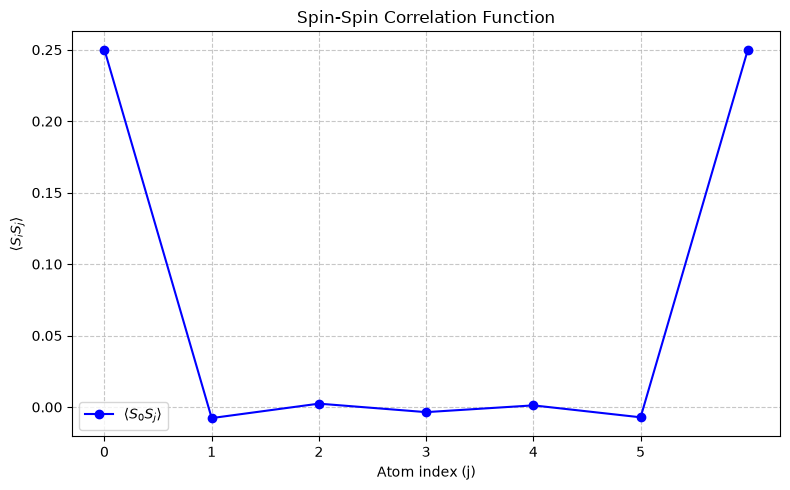

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Base directory where the run folders are stored
base_dir = "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs"
j_values_run = np.arange(1, 6)  

# 1. Extract values into a completely new Python list
SiSj_list = []

print("Extracting <S_i S_j> values...\n")

for j in j_values_run:
    folder_name = f"h_chain_3.78_rdm_i0j{j}_eval_new"
    file_path = os.path.join(base_dir, folder_name, "evaluation_digest.npz")
    
    try:
        digest = dict(np.load(file_path))
        SiSj = 0.25 * (
            digest['gamma2_uu_ijij'] + 
            digest['gamma2_dd_ijij'] - 
            digest['gamma2_ud_ijij'] - 
            digest['gamma2_ud_jiji']
        )
        if isinstance(SiSj, np.ndarray) and SiSj.ndim == 0:
            SiSj = SiSj.item()
            
        SiSj_list.append(SiSj)
        print(f"j = {j}: <S_i S_j> = {SiSj:.6f}")
        
    except FileNotFoundError:
        print(f"Warning: File not found for j={j} at {file_path}")
        SiSj_list.append(np.nan)

# 2. Safely create the 7-element arrays
# Front: 0.25, Middle: the 5 extracted values, Back: 0.25 -> Total length = 7
SiSj_values = np.array([0.25] + SiSj_list + [0.25])
j_values_plot = np.array([0, 1, 2, 3, 4, 5, 6])

# Verify shapes match before plotting
print(f"\nShape check -> x: {j_values_plot.shape}, y: {SiSj_values.shape}")

# 3. Plotting the results
plt.figure(figsize=(8, 5))

plt.plot(j_values_plot, SiSj_values, marker='o', linestyle='-', color='b', label=r'$\langle S_0 S_j \rangle$')

plt.title('Spin-Spin Correlation Function')
plt.xlabel('Atom index (j)')
plt.ylabel(r'$\langle S_i S_j \rangle$')

plt.xticks(np.arange(0, 6)) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig("SiSj_correlation.png", dpi=300)
print("Plot saved as 'SiSj_correlation.png'")

plt.show()

Plot saved as 'SiSj_correlation.png'


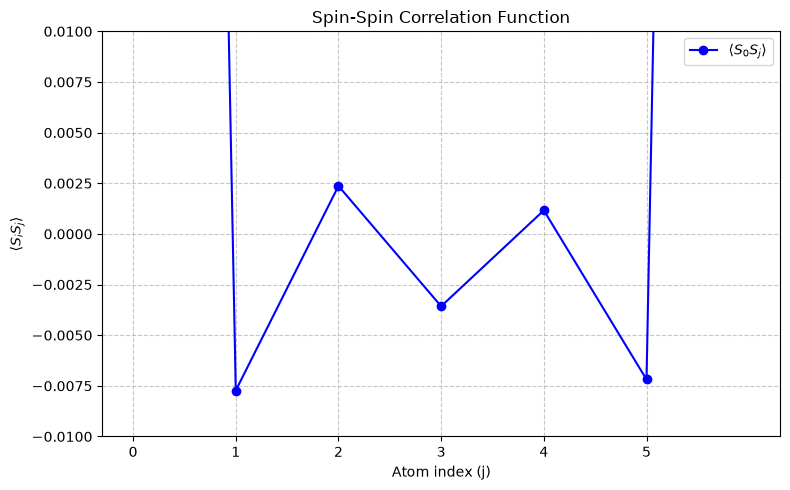

In [3]:
# 3. Plotting the results
plt.figure(figsize=(8, 5))

plt.plot(j_values_plot, SiSj_values, marker='o', linestyle='-', color='b', label=r'$\langle S_0 S_j \rangle$')

# ---------------------------------------------------------
# Set y-axis limits to +/- 0.01
# ---------------------------------------------------------
plt.ylim(-0.01, 0.01)

plt.title('Spin-Spin Correlation Function')
plt.xlabel('Atom index (j)')
plt.ylabel(r'$\langle S_i S_j \rangle$')
plt.xticks(np.arange(0, 6)) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig("SiSj_correlation.png", dpi=300)
print("Plot saved as 'SiSj_correlation.png'")

plt.show()

In [4]:
digest = dict(np.load(file_path))

print("Digest contents:")
for key, value in sorted(digest.items()):
    if value.ndim == 0:
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: shape={value.shape}")

SiSj = 0.25*(digest['gamma2_uu_ijij'] + digest['gamma2_dd_ijij'] - digest['gamma2_ud_ijij'] - digest['gamma2_ud_jiji'])
print(f"<S_i S_j>: {SiSj}")
#j=3

Digest contents:
  energy:kinetic: 2.627302-0.000009j
  energy:kinetic_var: 5.290747-0.000685j
  energy:potential: -5.713550
  energy:potential_var: 5.289811
  gamma1_down_ii: 0.122290-0.000026j
  gamma1_up_ii: 0.121984-0.000032j
  gamma2_dd_ijij: 0.007481-0.000003j
  gamma2_ud_ijij: 0.021617-0.000003j
  gamma2_ud_jiji: 0.020408-0.000007j
  gamma2_uu_ijij: 0.005801+0.000001j
  total_energy: -3.086248-0.000009j
  total_energy_real: -3.086248
  total_energy_real_var: 0.000896
<S_i S_j>: (-0.007185882888734341+1.8264415757585084e-06j)


# Corrected RDM code

Extracting <S_i S_j> values...

j = 1: <S_i S_j> = -0.008073+0.000002j
j = 2: <S_i S_j> = 0.003681-0.000001j
j = 3: <S_i S_j> = -0.002793-0.000004j
j = 4: <S_i S_j> = 0.002833-0.000003j
j = 5: <S_i S_j> = -0.007839-0.000004j

Shape check -> x: (7,), y: (7,)


/rds/user/jc2405/hpc-work/JaQMC/jaqmc/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/rds/user/jc2405/hpc-work/JaQMC/jaqmc/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


Plot saved as 'SiSj_correlation.png'


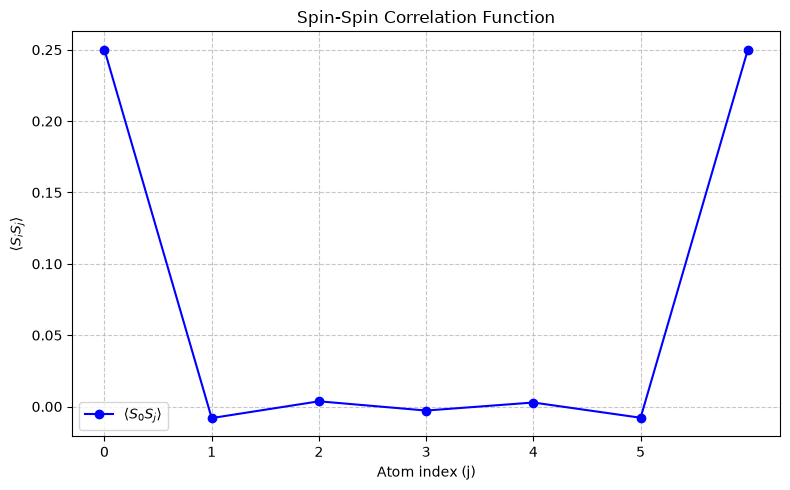

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Base directory where the run folders are stored
base_dir = "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs"
j_values_run = np.arange(1, 6)  

# 1. Extract values into a completely new Python list
SiSj_list = []

print("Extracting <S_i S_j> values...\n")

for j in j_values_run:
    folder_name = f"h_chain_3.78_rdm_i0j{j}_eval_new_correctf"
    file_path = os.path.join(base_dir, folder_name, "evaluation_digest.npz")
    
    try:
        digest = dict(np.load(file_path))
        SiSj = 0.25 * (
            digest['gamma2_uu_ijij'] + 
            digest['gamma2_dd_ijij'] - 
            digest['gamma2_ud_ijij'] - 
            digest['gamma2_ud_jiji']
        )
        if isinstance(SiSj, np.ndarray) and SiSj.ndim == 0:
            SiSj = SiSj.item()
            
        SiSj_list.append(SiSj)
        print(f"j = {j}: <S_i S_j> = {SiSj:.6f}")
        
    except FileNotFoundError:
        print(f"Warning: File not found for j={j} at {file_path}")
        SiSj_list.append(np.nan)

# 2. Safely create the 7-element arrays
# Front: 0.25, Middle: the 5 extracted values, Back: 0.25 -> Total length = 7
SiSj_values = np.array([0.25] + SiSj_list + [0.25])
j_values_plot = np.array([0, 1, 2, 3, 4, 5, 6])

# Verify shapes match before plotting
print(f"\nShape check -> x: {j_values_plot.shape}, y: {SiSj_values.shape}")

# 3. Plotting the results
plt.figure(figsize=(8, 5))

plt.plot(j_values_plot, SiSj_values, marker='o', linestyle='-', color='b', label=r'$\langle S_0 S_j \rangle$')

plt.title('Spin-Spin Correlation Function')
plt.xlabel('Atom index (j)')
plt.ylabel(r'$\langle S_i S_j \rangle$')

plt.xticks(np.arange(0, 6)) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig("SiSj_correlation.png", dpi=300)
print("Plot saved as 'SiSj_correlation.png'")

plt.show()

Plot saved as 'SiSj_correlation.png'


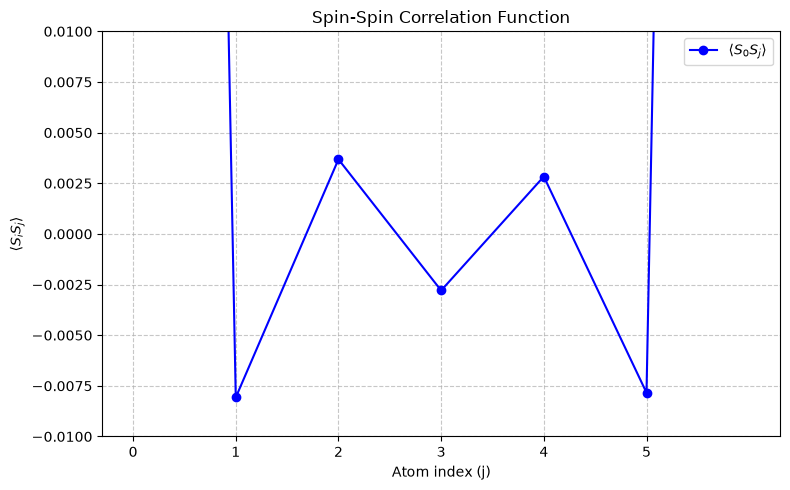

In [2]:
# 3. Plotting the results
plt.figure(figsize=(8, 5))

plt.plot(j_values_plot, SiSj_values, marker='o', linestyle='-', color='b', label=r'$\langle S_0 S_j \rangle$')

# ---------------------------------------------------------
# Set y-axis limits to +/- 0.01
# ---------------------------------------------------------
plt.ylim(-0.01, 0.01)

plt.title('Spin-Spin Correlation Function')
plt.xlabel('Atom index (j)')
plt.ylabel(r'$\langle S_i S_j \rangle$')
plt.xticks(np.arange(0, 6)) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig("SiSj_correlation.png", dpi=300)
print("Plot saved as 'SiSj_correlation.png'")

plt.show()

In [3]:
digest = dict(np.load(file_path))

print("Digest contents:")
for key, value in sorted(digest.items()):
    if value.ndim == 0:
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: shape={value.shape}")

SiSj = 0.25*(digest['gamma2_uu_ijij'] + digest['gamma2_dd_ijij'] - digest['gamma2_ud_ijij'] - digest['gamma2_ud_jiji'])
print(f"<S_i S_j>: {SiSj}")
#j=3

Digest contents:
  energy:kinetic: 2.641731+0.000001j
  energy:kinetic_var: 5.522864-0.002139j
  energy:potential: -5.728076
  energy:potential_var: 5.521531
  gamma1_down_ii: 0.125668+0.000090j
  gamma1_up_ii: 0.123714+0.000002j
  gamma2_dd_ijij: 0.004911+0.000001j
  gamma2_ud_ijij: 0.020811+0.000007j
  gamma2_ud_jiji: 0.021999+0.000003j
  gamma2_uu_ijij: 0.006544-0.000007j
  total_energy: -3.086345+0.000001j
  total_energy_real: -3.086345
  total_energy_real_var: 0.000893
<S_i S_j>: (-0.007838845252990723-4.038764018332586e-06j)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load your digest
path = "runs/h_chain_2.8_rdm_full_new_eval" 
digest_file = os.path.join(path, "evaluation_digest.npz")
digest = dict(np.load(digest_file))

# Extract the 1RDM arrays
# Standard JaQMC output keys for the 1-particle RDM
g1_u = digest['gamma1_up_ii']
g1_d = digest['gamma1_down_ii']

n_sites = 6

# =====================================================================
# 1. Calculate Occupancies
# =====================================================================
# The occupancy of the i-th orbital is the diagonal element [i, i] of the 1RDM
# Extract the diagonals and take the real part (imaginary part is QMC noise)
if g1_u.ndim == 1:
    occ_up = g1_u.real
    occ_down = g1_d.real
else:
    occ_up = np.diag(g1_u).real
    occ_down = np.diag(g1_d).real

# Total 1s occupancy per site is the sum of up and down spins
occ_total = occ_up + occ_down

# =====================================================================
# 2. Plotting
# =====================================================================
sites = np.arange(n_sites)

plt.figure(figsize=(10, 6))

# Plot total occupancy
plt.plot(sites, occ_total, marker='o', linestyle='-', color='black', linewidth=2, 
         label=r'Total Occupancy ($n_{\uparrow} + n_{\downarrow}$)')

# Plot individual spin channels to check for spin polarization symmetry
plt.plot(sites, occ_up, marker='^', linestyle='--', color='tab:red', alpha=0.8, 
         label=r'Spin-Up ($n_{\uparrow}$)')
plt.plot(sites, occ_down, marker='v', linestyle='--', color='tab:blue', alpha=0.8, 
         label=r'Spin-Down ($n_{\downarrow}$)')

# Draw a horizontal line at 1.0 (ideal half-filling reference)
# plt.axhline(1.0, color='gray', linewidth=1, linestyle=':', label='Ideal Half-Filling (1.0)')

plt.xlabel(r"Hydrogen Site Index $i$", fontsize=12)
plt.ylabel(r"1s Orbital Occupancy $\langle n_i \rangle$", fontsize=12)
plt.title(r"1s Orbital Occupancy along 1D Hydrogen Chain ($N=18$)", fontsize=14)
plt.xticks(sites)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# =====================================================================
# 3. Printing Summary Table
# =====================================================================
print("=== 1s Orbital Occupancies ===")
print("Site |   Up   |  Down  |  Total ")
print("-" * 35)
for i in range(n_sites):
    print(f" {i:2d}  | {occ_up[i]:.4f} | {occ_down[i]:.4f} | {occ_total[i]:.4f}")

## 6 H's 2.8 bohrs distance

In [3]:
digest = dict(np.load("/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_2.8_rdm_full_new_eval/evaluation_digest.npz"))

print("Digest contents:")
for key, value in sorted(digest.items()):
    if value.ndim == 0:
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: shape={value.shape}")


Digest contents:
  energy:kinetic: 2.548631-0.000009j
  energy:kinetic_var: 5.196256-0.000551j
  energy:potential: -5.824355
  energy:potential_var: 5.195722
  gamma1_down_ii: shape=(6,)
  gamma1_up_ii: shape=(6,)
  total_energy: -3.275724-0.000009j
  total_energy_real: -3.275724
  total_energy_real_var: 0.001416
  two_rdm_down_down: shape=(6, 6, 6, 6)
  two_rdm_up_down: shape=(6, 6, 6, 6)
  two_rdm_up_up: shape=(6, 6, 6, 6)


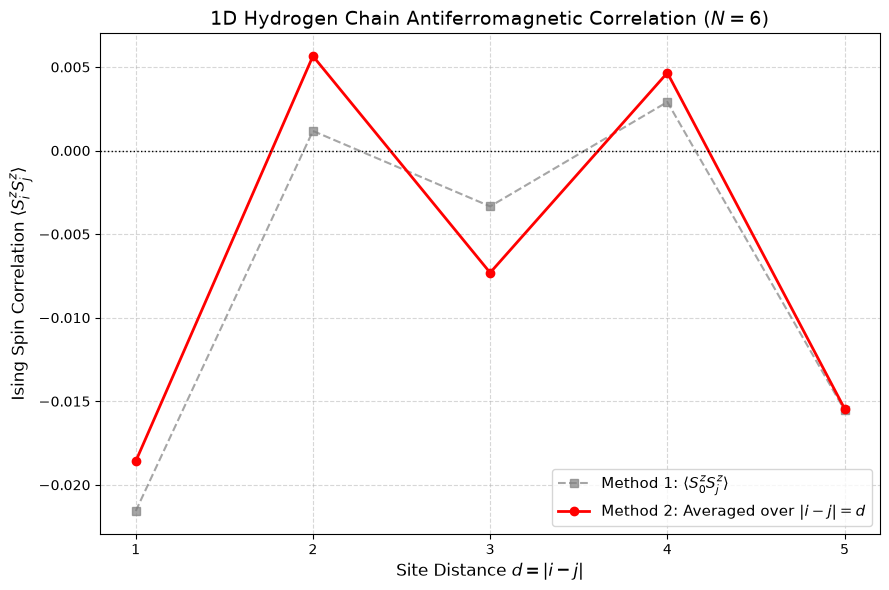

=== Detailed Pairs for each |i-j| ===

Distance d = 1:
  <S_0^z S_1^z> : -0.021570
  <S_1^z S_0^z> : -0.020570
  <S_1^z S_2^z> : -0.016727
  <S_2^z S_1^z> : -0.016432
  <S_2^z S_3^z> : -0.013943
  <S_3^z S_2^z> : -0.019523
  <S_3^z S_4^z> : -0.019802
  <S_4^z S_3^z> : -0.015915
  <S_4^z S_5^z> : -0.021224
  <S_5^z S_4^z> : -0.020221

Distance d = 2:
  <S_0^z S_2^z> : +0.001175
  <S_1^z S_3^z> : +0.004072
  <S_2^z S_0^z> : +0.007542
  <S_2^z S_4^z> : +0.006052
  <S_3^z S_1^z> : +0.006645
  <S_3^z S_5^z> : +0.004474
  <S_4^z S_2^z> : +0.008326
  <S_5^z S_3^z> : +0.006945

Distance d = 3:
  <S_0^z S_3^z> : -0.003339
  <S_1^z S_4^z> : -0.004702
  <S_2^z S_5^z> : -0.011650
  <S_3^z S_0^z> : -0.005873
  <S_4^z S_1^z> : -0.003693
  <S_5^z S_2^z> : -0.014587

Distance d = 4:
  <S_0^z S_4^z> : +0.002909
  <S_1^z S_5^z> : +0.004927
  <S_4^z S_0^z> : +0.008025
  <S_5^z S_1^z> : +0.002753

Distance d = 5:
  <S_0^z S_5^z> : -0.015532
  <S_5^z S_0^z> : -0.015343


=== Summary Table ===
Distance | Me

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load your digest
path = "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_2.8_rdm_full_new_eval" # Replace with your actual path
digest_file = os.path.join(path, "evaluation_digest.npz")
digest = dict(np.load(digest_file))

# Extract the 6-orbital 2RDM arrays
g2_uu = digest['two_rdm_up_up']
g2_dd = digest['two_rdm_down_down']
g2_ud = digest['two_rdm_up_down']

n_sites = 6

# =====================================================================
# 1. Build the <S_i^z S_j^z> Matrix
# =====================================================================
# Extract the ijij and jiji elements for the Ising term
nn_uu = np.einsum('ijij->ij', g2_uu)
nn_dd = np.einsum('ijij->ij', g2_dd)
nn_ud = np.einsum('ijij->ij', g2_ud)
nn_du = np.einsum('jiji->ij', g2_ud) 

# Apply your exact formula
sz_sz_matrix = (nn_uu + nn_dd - nn_ud - nn_du) # * 0.25 (remove to follow paper's scaling)

# Take the real part (imaginary part is just QMC noise)
sz_sz_matrix = sz_sz_matrix.real

# =====================================================================
# 2. Extract Correlations by Distance |i-j| (Skipping d=0)
# =====================================================================
# We start the range at 1 to skip the d=0 on-site value completely
distances = np.arange(1, n_sites) # 1 to 5

# Method 1: Anchored to i=0
correlations_m1 = [sz_sz_matrix[0, d] for d in distances]

# Method 2: Averaged over all translationally equivalent pairs (and storing pairs)
correlations_m2 = []
detailed_pairs = {}

for d in distances:
    pairs_for_d = []
    for i in range(n_sites):
        for j in range(n_sites):
            if abs(i - j) == d:
                pairs_for_d.append(((i, j), sz_sz_matrix[i, j]))
                
    # Calculate the average for Method 2
    avg_val = np.mean([val for _, val in pairs_for_d])
    correlations_m2.append(avg_val)
    detailed_pairs[d] = pairs_for_d

# =====================================================================
# 3. Plotting
# =====================================================================
plt.figure(figsize=(9, 6))

# Plot Method 1
plt.plot(distances, correlations_m1, marker='s', linestyle='--', color='gray', alpha=0.7, 
         label=r'Method 1: $\langle S_0^z S_j^z \rangle$')

# Plot Method 2
plt.plot(distances, correlations_m2, marker='o', linestyle='-', color='r', linewidth=2, 
         label=r'Method 2: Averaged over $|i-j|=d$')

# Draw a horizontal line at 0 for visual reference
plt.axhline(0, color='black', linewidth=1, linestyle=':')

plt.xlabel(r"Site Distance $d = |i - j|$", fontsize=12)
plt.ylabel(r"Ising Spin Correlation $\langle S_i^z S_j^z \rangle$", fontsize=12)
plt.title(r"1D Hydrogen Chain Antiferromagnetic Correlation ($N=6$)", fontsize=14)
plt.xticks(distances)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# =====================================================================
# 4. Printing Detailed Pair Outputs & Summary
# =====================================================================
print("=== Detailed Pairs for each |i-j| ===")
for d in distances:
    print(f"\nDistance d = {d}:")
    for (i, j), val in detailed_pairs[d]:
        print(f"  <S_{i}^z S_{j}^z> : {val:+.6f}")

print("\n\n=== Summary Table ===")
print("Distance | Method 1      | Method 2 (Averaged)")
print("-" * 50)
for d, v1, v2 in zip(distances, correlations_m1, correlations_m2):
    print(f"   {d}     |  {v1:+.6f}  |  {v2:+.6f}")

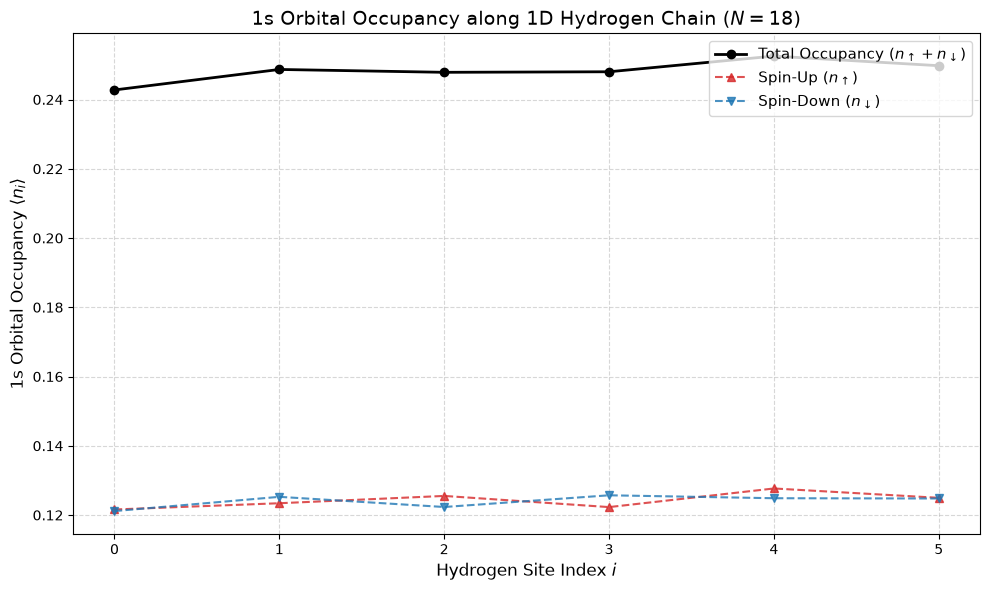

=== 1s Orbital Occupancies ===
Site |   Up   |  Down  |  Total 
-----------------------------------
  0  | 0.1216 | 0.1211 | 0.2428
  1  | 0.1234 | 0.1253 | 0.2487
  2  | 0.1255 | 0.1223 | 0.2479
  3  | 0.1223 | 0.1257 | 0.2480
  4  | 0.1277 | 0.1249 | 0.2525
  5  | 0.1250 | 0.1248 | 0.2498


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load your digest
path = "runs/h_chain_2.8_rdm_full_new_eval" 
digest_file = os.path.join(path, "evaluation_digest.npz")
digest = dict(np.load(digest_file))

# Extract the 1RDM arrays
# Standard JaQMC output keys for the 1-particle RDM
g1_u = digest['gamma1_up_ii']
g1_d = digest['gamma1_down_ii']

n_sites = 6

# =====================================================================
# 1. Calculate Occupancies
# =====================================================================
# The occupancy of the i-th orbital is the diagonal element [i, i] of the 1RDM
# Extract the diagonals and take the real part (imaginary part is QMC noise)
if g1_u.ndim == 1:
    occ_up = g1_u.real
    occ_down = g1_d.real
else:
    occ_up = np.diag(g1_u).real
    occ_down = np.diag(g1_d).real

# Total 1s occupancy per site is the sum of up and down spins
occ_total = occ_up + occ_down

# =====================================================================
# 2. Plotting
# =====================================================================
sites = np.arange(n_sites)

plt.figure(figsize=(10, 6))

# Plot total occupancy
plt.plot(sites, occ_total, marker='o', linestyle='-', color='black', linewidth=2, 
         label=r'Total Occupancy ($n_{\uparrow} + n_{\downarrow}$)')

# Plot individual spin channels to check for spin polarization symmetry
plt.plot(sites, occ_up, marker='^', linestyle='--', color='tab:red', alpha=0.8, 
         label=r'Spin-Up ($n_{\uparrow}$)')
plt.plot(sites, occ_down, marker='v', linestyle='--', color='tab:blue', alpha=0.8, 
         label=r'Spin-Down ($n_{\downarrow}$)')

# Draw a horizontal line at 1.0 (ideal half-filling reference)
# plt.axhline(1.0, color='gray', linewidth=1, linestyle=':', label='Ideal Half-Filling (1.0)')

plt.xlabel(r"Hydrogen Site Index $i$", fontsize=12)
plt.ylabel(r"1s Orbital Occupancy $\langle n_i \rangle$", fontsize=12)
plt.title(r"1s Orbital Occupancy along 1D Hydrogen Chain ($N=18$)", fontsize=14)
plt.xticks(sites)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# =====================================================================
# 3. Printing Summary Table
# =====================================================================
print("=== 1s Orbital Occupancies ===")
print("Site |   Up   |  Down  |  Total ")
print("-" * 35)
for i in range(n_sites):
    print(f" {i:2d}  | {occ_up[i]:.4f} | {occ_down[i]:.4f} | {occ_total[i]:.4f}")

### N = 18

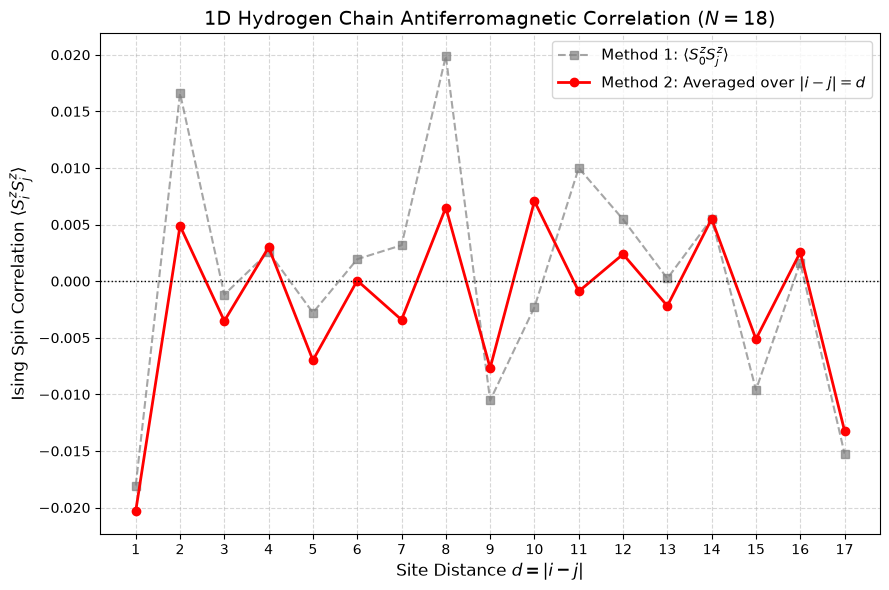

=== Detailed Pairs for each |i-j| ===

Distance d = 1:
  <S_0^z S_1^z> : -0.018052
  <S_1^z S_0^z> : -0.018257
  <S_1^z S_2^z> : -0.029195
  <S_2^z S_1^z> : -0.022085
  <S_2^z S_3^z> : -0.012422
  <S_3^z S_2^z> : -0.015012
  <S_3^z S_4^z> : -0.036893
  <S_4^z S_3^z> : -0.038612
  <S_4^z S_5^z> : -0.015233
  <S_5^z S_4^z> : -0.019150
  <S_5^z S_6^z> : -0.000333
  <S_6^z S_5^z> : -0.006836
  <S_6^z S_7^z> : -0.025362
  <S_7^z S_6^z> : -0.009193
  <S_7^z S_8^z> : -0.029572
  <S_8^z S_7^z> : -0.015565
  <S_8^z S_9^z> : -0.007275
  <S_9^z S_8^z> : -0.005615
  <S_9^z S_10^z> : -0.018848
  <S_10^z S_9^z> : -0.019947
  <S_10^z S_11^z> : -0.028367
  <S_11^z S_10^z> : -0.025526
  <S_11^z S_12^z> : -0.032298
  <S_12^z S_11^z> : -0.032838
  <S_12^z S_13^z> : -0.014983
  <S_13^z S_12^z> : -0.023444
  <S_13^z S_14^z> : -0.015763
  <S_14^z S_13^z> : -0.018380
  <S_14^z S_15^z> : -0.028334
  <S_15^z S_14^z> : -0.015902
  <S_15^z S_16^z> : -0.020934
  <S_16^z S_15^z> : -0.022630
  <S_16^z S_17^z> : -0.

In [11]:
#Eval 100 steps
import numpy as np
import matplotlib.pyplot as plt
import os

# Load your digest
path = "runs/h_chain_18_rdm_eval_all" 
digest_file = os.path.join(path, "evaluation_digest.npz")
digest = dict(np.load(digest_file))

# Extract the 18-orbital 2RDM arrays
g2_uu = digest['two_rdm_up_up']
g2_dd = digest['two_rdm_down_down']
g2_ud = digest['two_rdm_up_down']

n_sites = 18

# =====================================================================
# 1. Build the <S_i^z S_j^z> Matrix
# =====================================================================
# Extract the ijij and jiji elements for the Ising term
nn_uu = np.einsum('ijij->ij', g2_uu)
nn_dd = np.einsum('ijij->ij', g2_dd)
nn_ud = np.einsum('ijij->ij', g2_ud)
nn_du = np.einsum('jiji->ij', g2_ud) 

# Apply your exact formula
sz_sz_matrix = (nn_uu + nn_dd - nn_ud - nn_du) # * 0.25 (remove to follow paper's scaling)

# Take the real part (imaginary part is just QMC noise)
sz_sz_matrix = sz_sz_matrix.real

# =====================================================================
# 2. Extract Correlations by Distance |i-j| (Skipping d=0)
# =====================================================================
# We start the range at 1 to skip the d=0 on-site value completely
distances = np.arange(1, n_sites) # 1 to 17

# Method 1: Anchored to i=0
correlations_m1 = [sz_sz_matrix[0, d] for d in distances]

# Method 2: Averaged over all translationally equivalent pairs (and storing pairs)
correlations_m2 = []
detailed_pairs = {}

for d in distances:
    pairs_for_d = []
    for i in range(n_sites):
        for j in range(n_sites):
            if abs(i - j) == d:
                pairs_for_d.append(((i, j), sz_sz_matrix[i, j]))
                
    # Calculate the average for Method 2
    avg_val = np.mean([val for _, val in pairs_for_d])
    correlations_m2.append(avg_val)
    detailed_pairs[d] = pairs_for_d

# =====================================================================
# 3. Plotting
# =====================================================================
plt.figure(figsize=(9, 6))

# Plot Method 1
plt.plot(distances, correlations_m1, marker='s', linestyle='--', color='gray', alpha=0.7, 
         label=r'Method 1: $\langle S_0^z S_j^z \rangle$')

# Plot Method 2
plt.plot(distances, correlations_m2, marker='o', linestyle='-', color='r', linewidth=2, 
         label=r'Method 2: Averaged over $|i-j|=d$')

# Draw a horizontal line at 0 for visual reference
plt.axhline(0, color='black', linewidth=1, linestyle=':')

plt.xlabel(r"Site Distance $d = |i - j|$", fontsize=12)
plt.ylabel(r"Ising Spin Correlation $\langle S_i^z S_j^z \rangle$", fontsize=12)
plt.title(r"1D Hydrogen Chain Antiferromagnetic Correlation ($N=18$)", fontsize=14)
plt.xticks(distances)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# =====================================================================
# 4. Printing Detailed Pair Outputs & Summary
# =====================================================================
print("=== Detailed Pairs for each |i-j| ===")
for d in distances:
    print(f"\nDistance d = {d}:")
    for (i, j), val in detailed_pairs[d]:
        print(f"  <S_{i}^z S_{j}^z> : {val:+.6f}")

print("\n\n=== Summary Table ===")
print("Distance | Method 1      | Method 2 (Averaged)")
print("-" * 50)
for d, v1, v2 in zip(distances, correlations_m1, correlations_m2):
    print(f"   {d}     |  {v1:+.6f}  |  {v2:+.6f}")

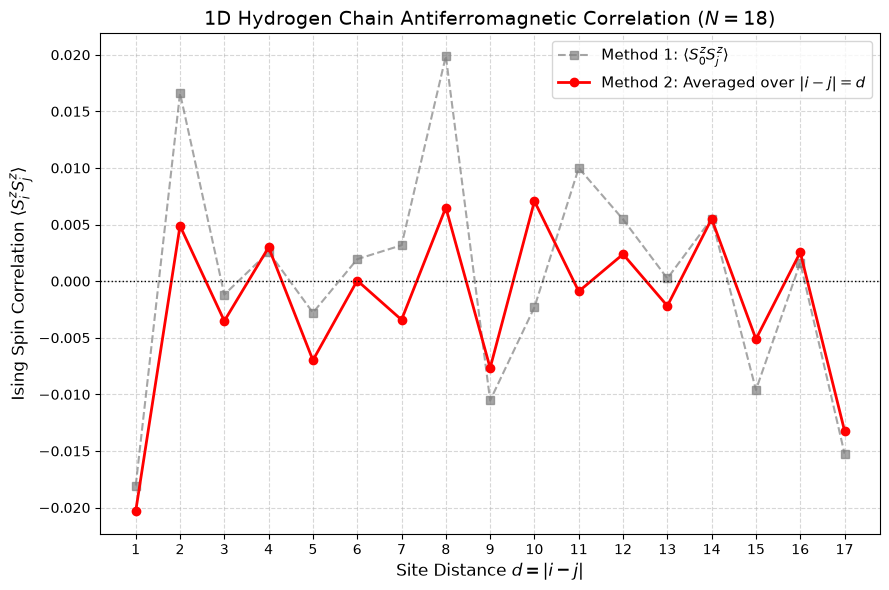

=== Detailed Pairs for each |i-j| ===

Distance d = 1:
  <S_0^z S_1^z> : -0.018052
  <S_1^z S_0^z> : -0.018257
  <S_1^z S_2^z> : -0.029195
  <S_2^z S_1^z> : -0.022085
  <S_2^z S_3^z> : -0.012422
  <S_3^z S_2^z> : -0.015012
  <S_3^z S_4^z> : -0.036893
  <S_4^z S_3^z> : -0.038612
  <S_4^z S_5^z> : -0.015233
  <S_5^z S_4^z> : -0.019150
  <S_5^z S_6^z> : -0.000333
  <S_6^z S_5^z> : -0.006836
  <S_6^z S_7^z> : -0.025362
  <S_7^z S_6^z> : -0.009193
  <S_7^z S_8^z> : -0.029572
  <S_8^z S_7^z> : -0.015565
  <S_8^z S_9^z> : -0.007275
  <S_9^z S_8^z> : -0.005615
  <S_9^z S_10^z> : -0.018848
  <S_10^z S_9^z> : -0.019947
  <S_10^z S_11^z> : -0.028367
  <S_11^z S_10^z> : -0.025526
  <S_11^z S_12^z> : -0.032298
  <S_12^z S_11^z> : -0.032838
  <S_12^z S_13^z> : -0.014983
  <S_13^z S_12^z> : -0.023444
  <S_13^z S_14^z> : -0.015763
  <S_14^z S_13^z> : -0.018380
  <S_14^z S_15^z> : -0.028334
  <S_15^z S_14^z> : -0.015902
  <S_15^z S_16^z> : -0.020934
  <S_16^z S_15^z> : -0.022630
  <S_16^z S_17^z> : -0.

In [12]:
#Eval 1513 steps
import numpy as np
import matplotlib.pyplot as plt
import os

# Load your digest
path = "runs/h_chain_18_rdm_eval_all" 
digest_file = os.path.join(path, "evaluation_digest.npz")
digest = dict(np.load(digest_file))

# Extract the 18-orbital 2RDM arrays
g2_uu = digest['two_rdm_up_up']
g2_dd = digest['two_rdm_down_down']
g2_ud = digest['two_rdm_up_down']

n_sites = 18

# =====================================================================
# 1. Build the <S_i^z S_j^z> Matrix
# =====================================================================
# Extract the ijij and jiji elements for the Ising term
nn_uu = np.einsum('ijij->ij', g2_uu)
nn_dd = np.einsum('ijij->ij', g2_dd)
nn_ud = np.einsum('ijij->ij', g2_ud)
nn_du = np.einsum('jiji->ij', g2_ud) 

# Apply your exact formula
sz_sz_matrix = (nn_uu + nn_dd - nn_ud - nn_du) # * 0.25 (remove to follow paper's scaling)

# Take the real part (imaginary part is just QMC noise)
sz_sz_matrix = sz_sz_matrix.real

# =====================================================================
# 2. Extract Correlations by Distance |i-j| (Skipping d=0)
# =====================================================================
# We start the range at 1 to skip the d=0 on-site value completely
distances = np.arange(1, n_sites) # 1 to 17

# Method 1: Anchored to i=0
correlations_m1 = [sz_sz_matrix[0, d] for d in distances]

# Method 2: Averaged over all translationally equivalent pairs (and storing pairs)
correlations_m2 = []
detailed_pairs = {}

for d in distances:
    pairs_for_d = []
    for i in range(n_sites):
        for j in range(n_sites):
            if abs(i - j) == d:
                pairs_for_d.append(((i, j), sz_sz_matrix[i, j]))
                
    # Calculate the average for Method 2
    avg_val = np.mean([val for _, val in pairs_for_d])
    correlations_m2.append(avg_val)
    detailed_pairs[d] = pairs_for_d

# =====================================================================
# 3. Plotting
# =====================================================================
plt.figure(figsize=(9, 6))

# Plot Method 1
plt.plot(distances, correlations_m1, marker='s', linestyle='--', color='gray', alpha=0.7, 
         label=r'Method 1: $\langle S_0^z S_j^z \rangle$')

# Plot Method 2
plt.plot(distances, correlations_m2, marker='o', linestyle='-', color='r', linewidth=2, 
         label=r'Method 2: Averaged over $|i-j|=d$')

# Draw a horizontal line at 0 for visual reference
plt.axhline(0, color='black', linewidth=1, linestyle=':')

plt.xlabel(r"Site Distance $d = |i - j|$", fontsize=12)
plt.ylabel(r"Ising Spin Correlation $\langle S_i^z S_j^z \rangle$", fontsize=12)
plt.title(r"1D Hydrogen Chain Antiferromagnetic Correlation ($N=18$)", fontsize=14)
plt.xticks(distances)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# =====================================================================
# 4. Printing Detailed Pair Outputs & Summary
# =====================================================================
print("=== Detailed Pairs for each |i-j| ===")
for d in distances:
    print(f"\nDistance d = {d}:")
    for (i, j), val in detailed_pairs[d]:
        print(f"  <S_{i}^z S_{j}^z> : {val:+.6f}")

print("\n\n=== Summary Table ===")
print("Distance | Method 1      | Method 2 (Averaged)")
print("-" * 50)
for d, v1, v2 in zip(distances, correlations_m1, correlations_m2):
    print(f"   {d}     |  {v1:+.6f}  |  {v2:+.6f}")

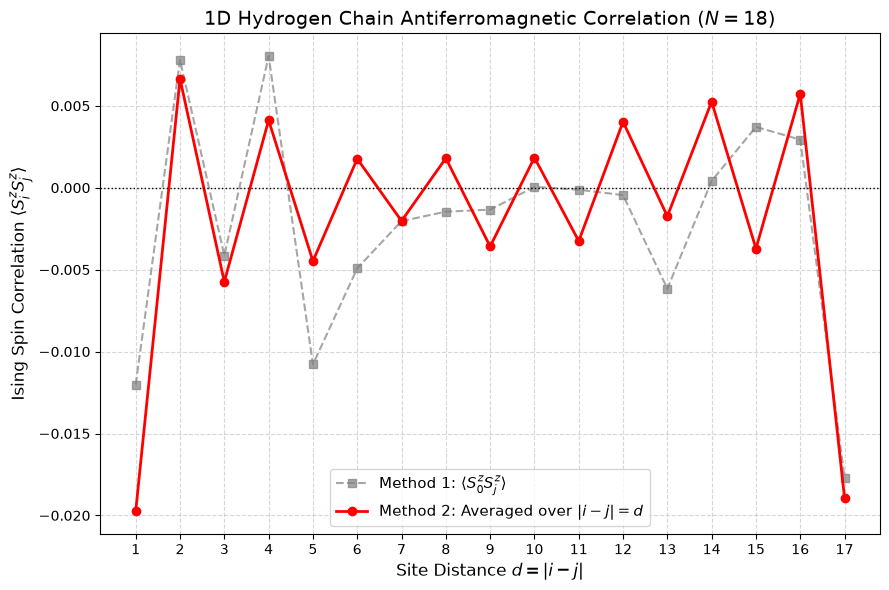

=== Detailed Pairs for each |i-j| ===

Distance d = 1:
  <S_0^z S_1^z> : -0.012009
  <S_1^z S_0^z> : -0.015507
  <S_1^z S_2^z> : -0.024098
  <S_2^z S_1^z> : -0.022927
  <S_2^z S_3^z> : -0.019916
  <S_3^z S_2^z> : -0.023004
  <S_3^z S_4^z> : -0.020209
  <S_4^z S_3^z> : -0.016956
  <S_4^z S_5^z> : -0.022089
  <S_5^z S_4^z> : -0.022091
  <S_5^z S_6^z> : -0.015746
  <S_6^z S_5^z> : -0.017448
  <S_6^z S_7^z> : -0.020228
  <S_7^z S_6^z> : -0.024207
  <S_7^z S_8^z> : -0.025102
  <S_8^z S_7^z> : -0.023416
  <S_8^z S_9^z> : -0.015170
  <S_9^z S_8^z> : -0.015888
  <S_9^z S_10^z> : -0.022686
  <S_10^z S_9^z> : -0.021870
  <S_10^z S_11^z> : -0.020403
  <S_11^z S_10^z> : -0.022718
  <S_11^z S_12^z> : -0.018446
  <S_12^z S_11^z> : -0.015945
  <S_12^z S_13^z> : -0.015369
  <S_13^z S_12^z> : -0.016938
  <S_13^z S_14^z> : -0.016699
  <S_14^z S_13^z> : -0.017085
  <S_14^z S_15^z> : -0.023046
  <S_15^z S_14^z> : -0.021940
  <S_15^z S_16^z> : -0.020426
  <S_16^z S_15^z> : -0.025426
  <S_16^z S_17^z> : -0.

In [1]:
#Eval 11000 steps
import numpy as np
import matplotlib.pyplot as plt
import os

# Load your digest
path = "runs/h_chain_18_rdm_eval_all" 
digest_file = os.path.join(path, "evaluation_digest.npz")
digest = dict(np.load(digest_file))

# Extract the 18-orbital 2RDM arrays
g2_uu = digest['two_rdm_up_up']
g2_dd = digest['two_rdm_down_down']
g2_ud = digest['two_rdm_up_down']

n_sites = 18

# =====================================================================
# 1. Build the <S_i^z S_j^z> Matrix
# =====================================================================
# Extract the ijij and jiji elements for the Ising term
nn_uu = np.einsum('ijij->ij', g2_uu)
nn_dd = np.einsum('ijij->ij', g2_dd)
nn_ud = np.einsum('ijij->ij', g2_ud)
nn_du = np.einsum('jiji->ij', g2_ud) 

# Apply your exact formula
sz_sz_matrix = (nn_uu + nn_dd - nn_ud - nn_du) # * 0.25 (remove to follow paper's scaling)

# Take the real part (imaginary part is just QMC noise)
sz_sz_matrix = sz_sz_matrix.real

# =====================================================================
# 2. Extract Correlations by Distance |i-j| (Skipping d=0)
# =====================================================================
# We start the range at 1 to skip the d=0 on-site value completely
distances = np.arange(1, n_sites) # 1 to 17

# Method 1: Anchored to i=0
correlations_m1 = [sz_sz_matrix[0, d] for d in distances]

# Method 2: Averaged over all translationally equivalent pairs (and storing pairs)
correlations_m2 = []
detailed_pairs = {}

for d in distances:
    pairs_for_d = []
    for i in range(n_sites):
        for j in range(n_sites):
            if abs(i - j) == d:
                pairs_for_d.append(((i, j), sz_sz_matrix[i, j]))
                
    # Calculate the average for Method 2
    avg_val = np.mean([val for _, val in pairs_for_d])
    correlations_m2.append(avg_val)
    detailed_pairs[d] = pairs_for_d

# =====================================================================
# 3. Plotting
# =====================================================================
plt.figure(figsize=(9, 6))

# Plot Method 1
plt.plot(distances, correlations_m1, marker='s', linestyle='--', color='gray', alpha=0.7, 
         label=r'Method 1: $\langle S_0^z S_j^z \rangle$')

# Plot Method 2
plt.plot(distances, correlations_m2, marker='o', linestyle='-', color='r', linewidth=2, 
         label=r'Method 2: Averaged over $|i-j|=d$')

# Draw a horizontal line at 0 for visual reference
plt.axhline(0, color='black', linewidth=1, linestyle=':')

plt.xlabel(r"Site Distance $d = |i - j|$", fontsize=12)
plt.ylabel(r"Ising Spin Correlation $\langle S_i^z S_j^z \rangle$", fontsize=12)
plt.title(r"1D Hydrogen Chain Antiferromagnetic Correlation ($N=18$)", fontsize=14)
plt.xticks(distances)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# =====================================================================
# 4. Printing Detailed Pair Outputs & Summary
# =====================================================================
print("=== Detailed Pairs for each |i-j| ===")
for d in distances:
    print(f"\nDistance d = {d}:")
    for (i, j), val in detailed_pairs[d]:
        print(f"  <S_{i}^z S_{j}^z> : {val:+.6f}")

print("\n\n=== Summary Table ===")
print("Distance | Method 1      | Method 2 (Averaged)")
print("-" * 50)
for d, v1, v2 in zip(distances, correlations_m1, correlations_m2):
    print(f"   {d}     |  {v1:+.6f}  |  {v2:+.6f}")

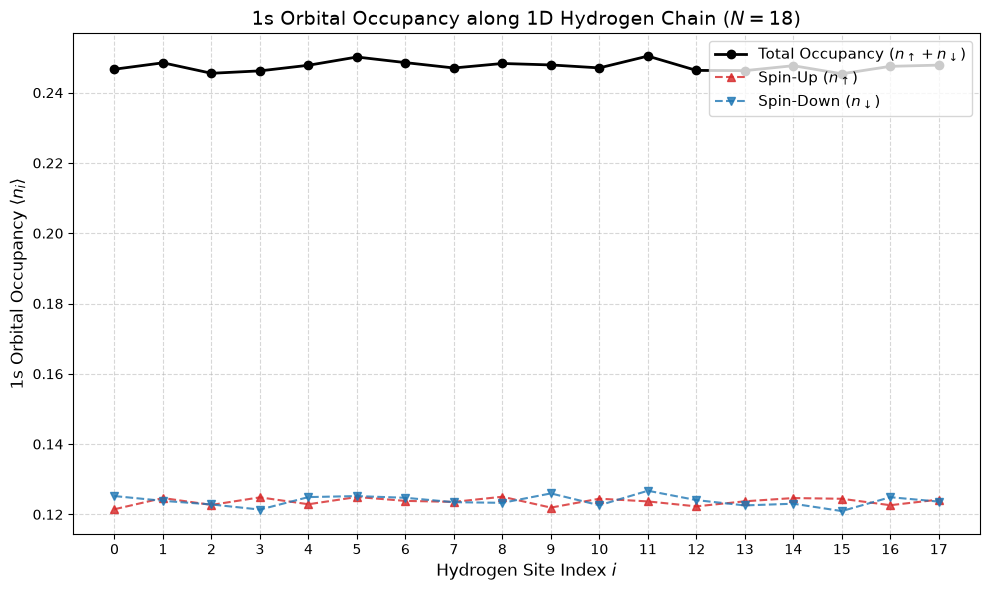

=== 1s Orbital Occupancies ===
Site |   Up   |  Down  |  Total 
-----------------------------------
  0  | 0.1215 | 0.1252 | 0.2467
  1  | 0.1246 | 0.1239 | 0.2485
  2  | 0.1227 | 0.1228 | 0.2455
  3  | 0.1248 | 0.1214 | 0.2462
  4  | 0.1229 | 0.1249 | 0.2478
  5  | 0.1249 | 0.1252 | 0.2502
  6  | 0.1238 | 0.1247 | 0.2486
  7  | 0.1236 | 0.1235 | 0.2470
  8  | 0.1250 | 0.1233 | 0.2483
  9  | 0.1219 | 0.1260 | 0.2479
 10  | 0.1245 | 0.1226 | 0.2471
 11  | 0.1237 | 0.1267 | 0.2504
 12  | 0.1223 | 0.1241 | 0.2463
 13  | 0.1237 | 0.1226 | 0.2463
 14  | 0.1246 | 0.1230 | 0.2477
 15  | 0.1244 | 0.1209 | 0.2454
 16  | 0.1226 | 0.1249 | 0.2475
 17  | 0.1242 | 0.1236 | 0.2478


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load your digest
path = "runs/h_chain_18_rdm_eval_all" 
digest_file = os.path.join(path, "evaluation_digest.npz")
digest = dict(np.load(digest_file))

# Extract the 1RDM arrays
# Standard JaQMC output keys for the 1-particle RDM
g1_u = digest['gamma1_up_ii']
g1_d = digest['gamma1_down_ii']

n_sites = 18

# =====================================================================
# 1. Calculate Occupancies
# =====================================================================
# The occupancy of the i-th orbital is the diagonal element [i, i] of the 1RDM
# Extract the diagonals and take the real part (imaginary part is QMC noise)
if g1_u.ndim == 1:
    occ_up = g1_u.real
    occ_down = g1_d.real
else:
    occ_up = np.diag(g1_u).real
    occ_down = np.diag(g1_d).real

# Total 1s occupancy per site is the sum of up and down spins
occ_total = occ_up + occ_down

# =====================================================================
# 2. Plotting
# =====================================================================
sites = np.arange(n_sites)

plt.figure(figsize=(10, 6))

# Plot total occupancy
plt.plot(sites, occ_total, marker='o', linestyle='-', color='black', linewidth=2, 
         label=r'Total Occupancy ($n_{\uparrow} + n_{\downarrow}$)')

# Plot individual spin channels to check for spin polarization symmetry
plt.plot(sites, occ_up, marker='^', linestyle='--', color='tab:red', alpha=0.8, 
         label=r'Spin-Up ($n_{\uparrow}$)')
plt.plot(sites, occ_down, marker='v', linestyle='--', color='tab:blue', alpha=0.8, 
         label=r'Spin-Down ($n_{\downarrow}$)')

# Draw a horizontal line at 1.0 (ideal half-filling reference)
# plt.axhline(1.0, color='gray', linewidth=1, linestyle=':', label='Ideal Half-Filling (1.0)')

plt.xlabel(r"Hydrogen Site Index $i$", fontsize=12)
plt.ylabel(r"1s Orbital Occupancy $\langle n_i \rangle$", fontsize=12)
plt.title(r"1s Orbital Occupancy along 1D Hydrogen Chain ($N=18$)", fontsize=14)
plt.xticks(sites)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# =====================================================================
# 3. Printing Summary Table
# =====================================================================
print("=== 1s Orbital Occupancies ===")
print("Site |   Up   |  Down  |  Total ")
print("-" * 35)
for i in range(n_sites):
    print(f" {i:2d}  | {occ_up[i]:.4f} | {occ_down[i]:.4f} | {occ_total[i]:.4f}")

Available datasets: ['Ni_sq', 'energy:kinetic', 'energy:kinetic_var', 'energy:potential', 'energy:potential_var', 'total_energy', 'total_energy_real', 'total_energy_real_var', 'unnorm_gamma1_down_ii', 'unnorm_gamma1_up_ii', 'unnorm_two_rdm_down_down', 'unnorm_two_rdm_up_down', 'unnorm_two_rdm_up_up']


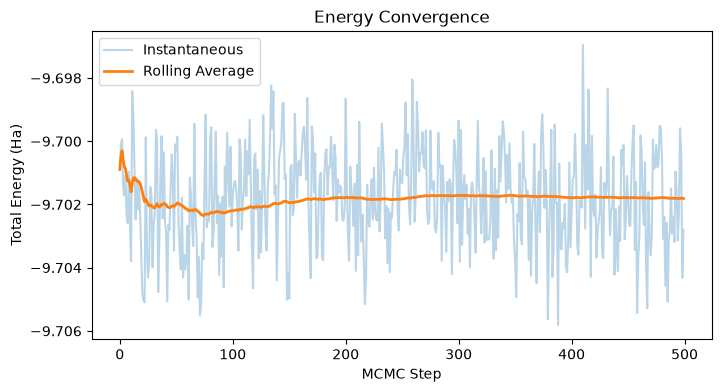

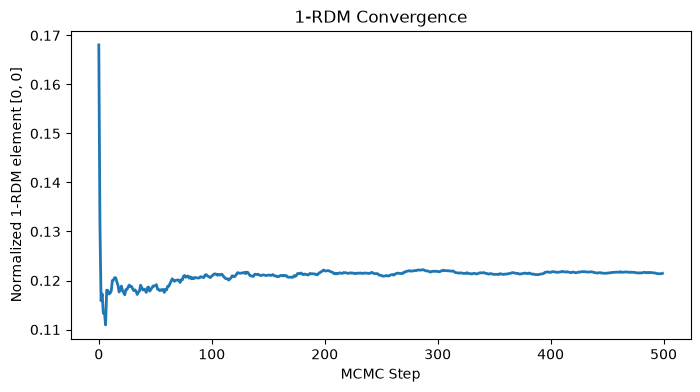

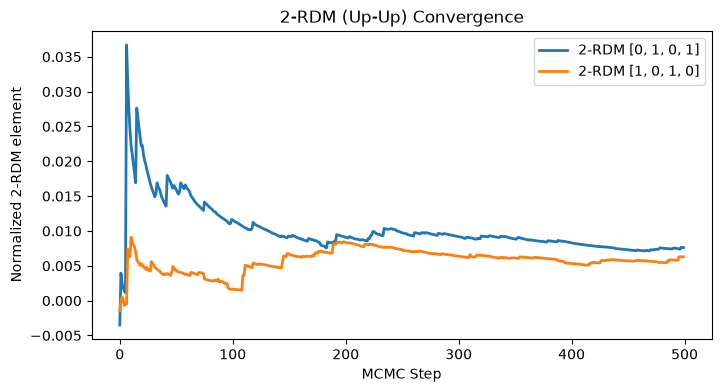

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Path to your evaluation stats file
h5_path = "runs/h_chain_18_rdm_eval_all/evaluation_stats.h5"

with h5py.File(h5_path, "r") as f:
    print("Available datasets:", list(f.keys()))
    
    # 1. Look at total energy convergence
    if 'total_energy_real' in f:
        energy = f['total_energy_real'][:]
        rolling_energy = np.cumsum(energy) / np.arange(1, len(energy) + 1)
        
        plt.figure(figsize=(8, 4))
        plt.plot(energy, alpha=0.3, label="Instantaneous")
        plt.plot(rolling_energy, linewidth=2, label="Rolling Average")
        plt.xlabel("MCMC Step")
        plt.ylabel("Total Energy (Ha)")
        plt.legend()
        plt.title("Energy Convergence")
        plt.show()

    # 2. Look at RDM convergence for a specific element, e.g., index [0, 1]
    if 'unnorm_gamma1_up_ii' in f and 'Ni_sq' in f:
        unnorm_gamma1 = f['unnorm_gamma1_up_ii'][:]
        ni_sq_i = f['Ni_sq'][:]
        
        # Calculate the normalized value at each step
        # Note: If your normalization Ni_sq is also accumulated over steps, 
        # you might want to use the rolling average of BOTH before dividing
        roll_unnorm = np.cumsum(unnorm_gamma1, axis=0) / np.arange(1, len(unnorm_gamma1) + 1)[:, None]
        roll_ni = np.cumsum(ni_sq_i, axis=0) / np.arange(1, len(ni_sq_i) + 1)[:, None]
        
        # Gamma normalized step-by-step
        roll_gamma1 = roll_unnorm / roll_ni
        
        # Let's say we want to plot the convergence of the 1-RDM element [0]
        plt.figure(figsize=(8, 4))
        plt.plot(roll_gamma1[:, 0], linewidth=2)
        plt.xlabel("MCMC Step")
        plt.ylabel("Normalized 1-RDM element [0, 0]")
        plt.title("1-RDM Convergence")
        plt.show()

    if 'unnorm_two_rdm_up_up' in f and 'Ni_sq' in f:
        unnorm_gamma2 = f['unnorm_two_rdm_up_up'][:]  # Shape: (steps, N_orbs, N_orbs, N_orbs, N_orbs)
        ni_sq = f['Ni_sq'][:]                         # Shape: (steps, N_orbs)
        
        # Calculate rolling averages over MCMC steps for the numerator
        roll_unnorm_gamma2 = np.cumsum(unnorm_gamma2, axis=0) / np.arange(1, len(unnorm_gamma2) + 1)[:, None, None, None, None]
        
        # Calculate rolling averages over MCMC steps for the normalizer
        roll_ni = np.cumsum(ni_sq, axis=0) / np.arange(1, len(ni_sq) + 1)[:, None]
        
        # For the full 2-RDM tensor (i, j, k, l), the normalizer is sqrt(N_i^2 * N_j^2 * N_k^2 * N_l^2)
        # Using broadcasting to construct the 4D normalization tensor
        norm_2rdm = np.sqrt(
            roll_ni[:, :, None, None, None] * 
            roll_ni[:, None, :, None, None] * 
            roll_ni[:, None, None, :, None] * 
            roll_ni[:, None, None, None, :]
        )
        
        # Gamma2 normalized step-by-step
        roll_gamma2 = roll_unnorm_gamma2 / norm_2rdm
        
        # Plot convergence of specific 2-RDM elements, e.g. [0, 1, 0, 1] and [1, 0, 1, 0]
        plt.figure(figsize=(8, 4))
        plt.plot(roll_gamma2[:, 0, 1, 0, 1], linewidth=2, label="2-RDM [0, 1, 0, 1]")
        plt.plot(roll_gamma2[:, 1, 0, 1, 0], linewidth=2, label="2-RDM [1, 0, 1, 0]")
        
        plt.xlabel("MCMC Step")
        plt.ylabel("Normalized 2-RDM element")
        plt.title("2-RDM (Up-Up) Convergence")
        plt.legend()
        plt.show()

Available columns: ['step', 'energy:kinetic', 'energy:kinetic_var', 'energy:potential', 'energy:potential_var', 'loss', 'pmove', 'total_energy', 'total_energy_real', 'total_energy_real_var']
ckpt1
Number of points: 37645
Energy range: -9.710404396057127 15.829729080200195
Variance range: 0.0067825317382812 56.14728546142578
Kinetic range: 7.648026943206787 29.735511779785156
Potential range: -17.92861557006836 -13.852886199951172
pmove range: 0.4986328184604645 0.7047119140625
ckpt2
ckpt3
ckpt4
ckpt5
ckpt6
ckpt7


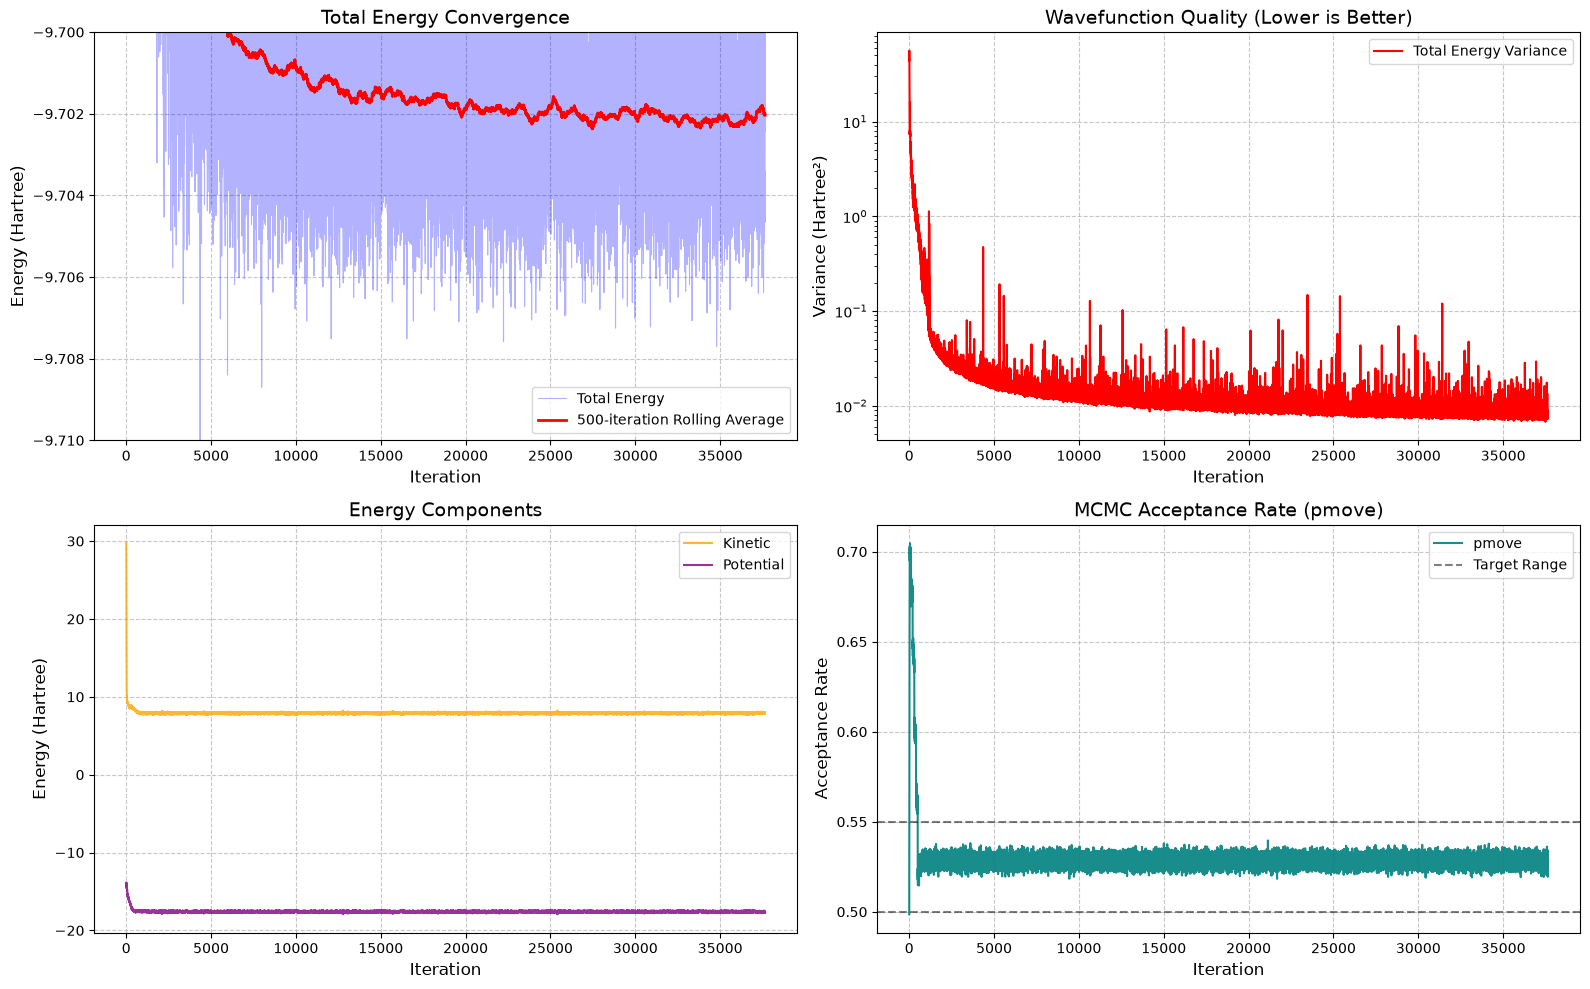

ckpt8


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Define the file path
file_path = "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_2.8_18/train_stats.csv"

if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}")
else:
    # Read the CSV file
    stats = pd.read_csv(file_path)

    print("Available columns:", list(stats.columns))

    # ---------------------------------------------------------
    # Extract data
    # ---------------------------------------------------------
    steps = stats["step"].to_numpy()

    # Use explicitly real-valued total energy
    total_energy = stats["total_energy_real"].to_numpy()

    # Convert complex-valued kinetic energy to real part
    kinetic = stats["energy:kinetic"].apply(
        lambda x: np.real(complex(x))
    ).to_numpy()

    # Potential energy is already real-valued
    potential = stats["energy:potential"].to_numpy()

    # Explicitly real-valued variance
    total_energy_var = stats["total_energy_real_var"].to_numpy()

    # MCMC acceptance probability
    pmove = stats["pmove"].to_numpy()

    print("ckpt1")
    print("Number of points:", len(steps))
    print("Energy range:", np.min(total_energy), np.max(total_energy))
    print("Variance range:", np.min(total_energy_var), np.max(total_energy_var))
    print("Kinetic range:", np.min(kinetic), np.max(kinetic))
    print("Potential range:", np.min(potential), np.max(potential))
    print("pmove range:", np.min(pmove), np.max(pmove))

    # ---------------------------------------------------------
    # Create figure
    # ---------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()


    # ---------------------------------------------------------
    # Plot 1: Total Energy Convergence
    # ---------------------------------------------------------
    # Rolling average of total energy
    window = 500
    energy_rolling = pd.Series(total_energy).rolling(window=window).mean()
    
    # Plot raw energy
    axes[0].plot(
        steps,
        total_energy,
        label="Total Energy",
        color="blue",
        linewidth=0.8,
        alpha=0.3
    )
    
    # Plot rolling average
    axes[0].plot(
        steps,
        energy_rolling,
        label=f"{window}-iteration Rolling Average",
        color="red",
        linewidth=2
    )
    
    axes[0].set_xlabel("Iteration", fontsize=12)
    axes[0].set_ylabel("Energy (Hartree)", fontsize=12)
    axes[0].set_title("Total Energy Convergence", fontsize=14)
    axes[0].set_ylim(top=-9.70, bottom=-9.71)
    axes[0].grid(True, linestyle="--", alpha=0.7)
    axes[0].legend()


    # ---------------------------------------------------------
    # Plot 2: Total Energy Variance
    # ---------------------------------------------------------
    axes[1].semilogy(
        steps,
        total_energy_var,
        label="Total Energy Variance",
        color="red",
        linewidth=1.5
    )

    axes[1].set_xlabel("Iteration", fontsize=12)
    axes[1].set_ylabel("Variance (Hartree²)", fontsize=12)
    axes[1].set_title(
        "Wavefunction Quality (Lower is Better)",
        fontsize=14
    )

    axes[1].grid(True, linestyle="--", alpha=0.7)
    axes[1].legend()


    # ---------------------------------------------------------
    # Plot 3: Energy Components
    # ---------------------------------------------------------
    axes[2].plot(
        steps,
        kinetic,
        label="Kinetic",
        color="orange",
        alpha=0.8
    )

    axes[2].plot(
        steps,
        potential,
        label="Potential",
        color="purple",
        alpha=0.8
    )

    axes[2].set_xlabel("Iteration", fontsize=12)
    axes[2].set_ylabel("Energy (Hartree)", fontsize=12)
    axes[2].set_title("Energy Components", fontsize=14)

    axes[2].grid(True, linestyle="--", alpha=0.7)
    axes[2].legend()


    # ---------------------------------------------------------
    # Plot 4: MCMC Acceptance Rate
    # ---------------------------------------------------------
    axes[3].plot(
        steps,
        pmove,
        label="pmove",
        color="teal",
        alpha=0.9
    )

    axes[3].axhline(
        y=0.55,
        color="black",
        linestyle="--",
        alpha=0.5,
        label="Target Range"
    )

    axes[3].axhline(
        y=0.50,
        color="black",
        linestyle="--",
        alpha=0.5
    )

    axes[3].set_xlabel("Iteration", fontsize=12)
    axes[3].set_ylabel("Acceptance Rate", fontsize=12)
    axes[3].set_title(
        "MCMC Acceptance Rate (pmove)",
        fontsize=14
    )

    axes[3].grid(True, linestyle="--", alpha=0.7)
    axes[3].legend()



    # ---------------------------------------------------------
    # Layout and display
    # ---------------------------------------------------------
    plt.tight_layout()



    plt.show()



# Gaussian initialized walkers based on orbital counts (manually generated digest npz)

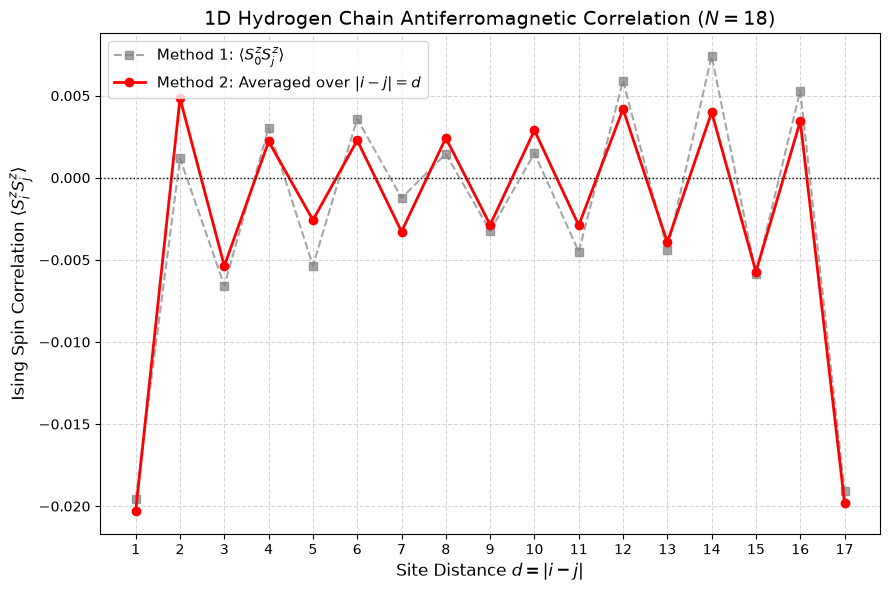

=== Detailed Pairs for each |i-j| ===

Distance d = 1:
  <S_0^z S_1^z> : -0.019578
  <S_1^z S_0^z> : -0.021699
  <S_1^z S_2^z> : -0.021015
  <S_2^z S_1^z> : -0.019985
  <S_2^z S_3^z> : -0.020646
  <S_3^z S_2^z> : -0.020145
  <S_3^z S_4^z> : -0.021226
  <S_4^z S_3^z> : -0.021985
  <S_4^z S_5^z> : -0.018095
  <S_5^z S_4^z> : -0.018173
  <S_5^z S_6^z> : -0.018211
  <S_6^z S_5^z> : -0.018061
  <S_6^z S_7^z> : -0.019849
  <S_7^z S_6^z> : -0.019743
  <S_7^z S_8^z> : -0.020417
  <S_8^z S_7^z> : -0.020589
  <S_8^z S_9^z> : -0.021904
  <S_9^z S_8^z> : -0.020672
  <S_9^z S_10^z> : -0.021152
  <S_10^z S_9^z> : -0.020907
  <S_10^z S_11^z> : -0.021459
  <S_11^z S_10^z> : -0.021736
  <S_11^z S_12^z> : -0.020584
  <S_12^z S_11^z> : -0.020991
  <S_12^z S_13^z> : -0.020694
  <S_13^z S_12^z> : -0.020519
  <S_13^z S_14^z> : -0.020239
  <S_14^z S_13^z> : -0.020281
  <S_14^z S_15^z> : -0.021212
  <S_15^z S_14^z> : -0.021641
  <S_15^z S_16^z> : -0.018913
  <S_16^z S_15^z> : -0.021331
  <S_16^z S_17^z> : -0.

In [1]:
#Eval 2000 steps
import numpy as np
import matplotlib.pyplot as plt
import os

# Load your digest /rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_18_rdm_eval_all_gaussian_init
path = "runs/h_chain_18_rdm_eval_all_gaussian_init" 
digest_file = os.path.join(path, "evaluation_digest.npz")
digest = dict(np.load(digest_file))

# Extract the 18-orbital 2RDM arrays
g2_uu = digest['two_rdm_up_up']
g2_dd = digest['two_rdm_down_down']
g2_ud = digest['two_rdm_up_down']

n_sites = 18

# =====================================================================
# 1. Build the <S_i^z S_j^z> Matrix
# =====================================================================
# Extract the ijij and jiji elements for the Ising term
nn_uu = np.einsum('ijij->ij', g2_uu)
nn_dd = np.einsum('ijij->ij', g2_dd)
nn_ud = np.einsum('ijij->ij', g2_ud)
nn_du = np.einsum('jiji->ij', g2_ud) 

# Apply your exact formula
sz_sz_matrix = (nn_uu + nn_dd - nn_ud - nn_du) # * 0.25 (remove to follow paper's scaling)

# Take the real part (imaginary part is just QMC noise)
sz_sz_matrix = sz_sz_matrix.real

# =====================================================================
# 2. Extract Correlations by Distance |i-j| (Skipping d=0)
# =====================================================================
# We start the range at 1 to skip the d=0 on-site value completely
distances = np.arange(1, n_sites) # 1 to 17

# Method 1: Anchored to i=0
correlations_m1 = [sz_sz_matrix[0, d] for d in distances]

# Method 2: Averaged over all translationally equivalent pairs (and storing pairs)
correlations_m2 = []
detailed_pairs = {}

for d in distances:
    pairs_for_d = []
    for i in range(n_sites):
        for j in range(n_sites):
            if abs(i - j) == d:
                pairs_for_d.append(((i, j), sz_sz_matrix[i, j]))
                
    # Calculate the average for Method 2
    avg_val = np.mean([val for _, val in pairs_for_d])
    correlations_m2.append(avg_val)
    detailed_pairs[d] = pairs_for_d

# =====================================================================
# 3. Plotting
# =====================================================================
plt.figure(figsize=(9, 6))

# Plot Method 1
plt.plot(distances, correlations_m1, marker='s', linestyle='--', color='gray', alpha=0.7, 
         label=r'Method 1: $\langle S_0^z S_j^z \rangle$')

# Plot Method 2
plt.plot(distances, correlations_m2, marker='o', linestyle='-', color='r', linewidth=2, 
         label=r'Method 2: Averaged over $|i-j|=d$')

# Draw a horizontal line at 0 for visual reference
plt.axhline(0, color='black', linewidth=1, linestyle=':')

plt.xlabel(r"Site Distance $d = |i - j|$", fontsize=12)
plt.ylabel(r"Ising Spin Correlation $\langle S_i^z S_j^z \rangle$", fontsize=12)
plt.title(r"1D Hydrogen Chain Antiferromagnetic Correlation ($N=18$)", fontsize=14)
plt.xticks(distances)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# =====================================================================
# 4. Printing Detailed Pair Outputs & Summary
# =====================================================================
print("=== Detailed Pairs for each |i-j| ===")
for d in distances:
    print(f"\nDistance d = {d}:")
    for (i, j), val in detailed_pairs[d]:
        print(f"  <S_{i}^z S_{j}^z> : {val:+.6f}")

print("\n\n=== Summary Table ===")
print("Distance | Method 1      | Method 2 (Averaged)")
print("-" * 50)
for d, v1, v2 in zip(distances, correlations_m1, correlations_m2):
    print(f"   {d}     |  {v1:+.6f}  |  {v2:+.6f}")

Available datasets: ['Ni_sq', 'energy:kinetic', 'energy:kinetic_var', 'energy:potential', 'energy:potential_var', 'total_energy', 'total_energy_real', 'total_energy_real_var', 'unnorm_gamma1_down_ii', 'unnorm_gamma1_up_ii', 'unnorm_two_rdm_down_down', 'unnorm_two_rdm_up_down', 'unnorm_two_rdm_up_up']


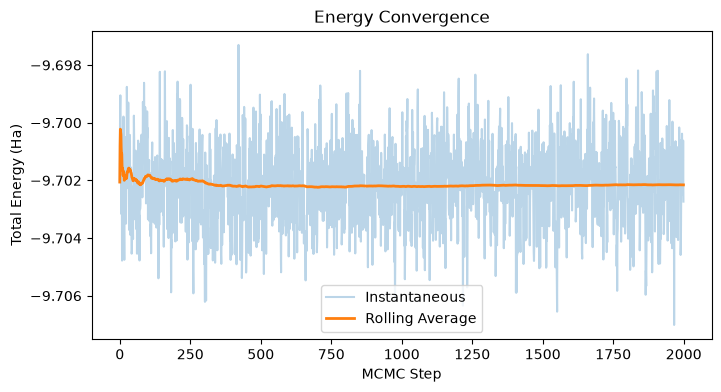

/rds/user/jc2405/hpc-work/JaQMC/jaqmc/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/rds/user/jc2405/hpc-work/JaQMC/jaqmc/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


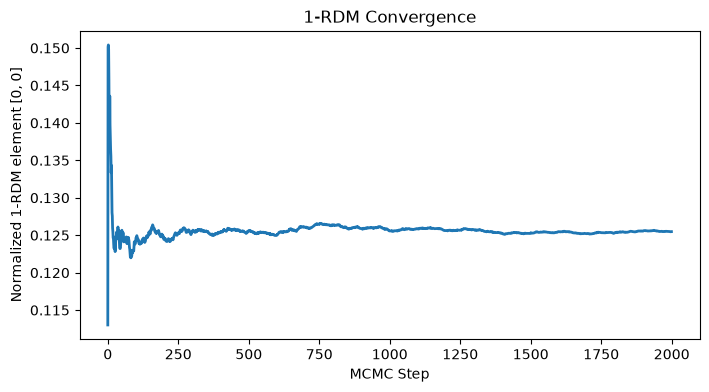

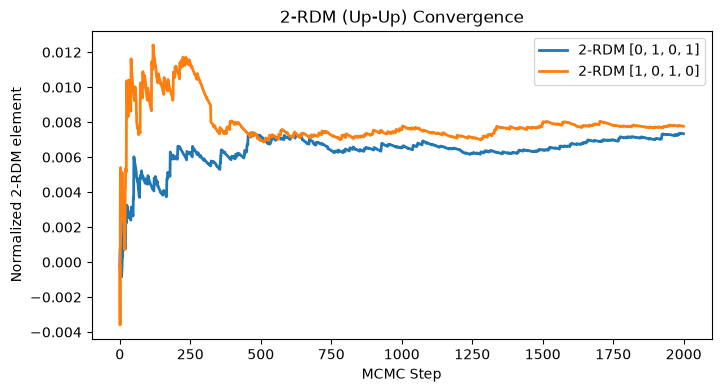

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Path to your evaluation stats file
h5_path = "runs/h_chain_18_rdm_eval_all_gaussian_init/evaluation_stats.h5"

with h5py.File(h5_path, "r") as f:
    print("Available datasets:", list(f.keys()))
    
    # 1. Look at total energy convergence
    if 'total_energy_real' in f:
        energy = f['total_energy_real'][:]
        rolling_energy = np.cumsum(energy) / np.arange(1, len(energy) + 1)
        
        plt.figure(figsize=(8, 4))
        plt.plot(energy, alpha=0.3, label="Instantaneous")
        plt.plot(rolling_energy, linewidth=2, label="Rolling Average")
        plt.xlabel("MCMC Step")
        plt.ylabel("Total Energy (Ha)")
        plt.legend()
        plt.title("Energy Convergence")
        plt.show()

    # 2. Look at RDM convergence for a specific element, e.g., index [0, 1]
    if 'unnorm_gamma1_up_ii' in f and 'Ni_sq' in f:
        unnorm_gamma1 = f['unnorm_gamma1_up_ii'][:]
        ni_sq_i = f['Ni_sq'][:]
        
        # Calculate the normalized value at each step
        # Note: If your normalization Ni_sq is also accumulated over steps, 
        # you might want to use the rolling average of BOTH before dividing
        roll_unnorm = np.cumsum(unnorm_gamma1, axis=0) / np.arange(1, len(unnorm_gamma1) + 1)[:, None]
        roll_ni = np.cumsum(ni_sq_i, axis=0) / np.arange(1, len(ni_sq_i) + 1)[:, None]
        
        # Gamma normalized step-by-step
        roll_gamma1 = roll_unnorm / roll_ni
        
        # Let's say we want to plot the convergence of the 1-RDM element [0]
        plt.figure(figsize=(8, 4))
        plt.plot(roll_gamma1[:, 0], linewidth=2)
        plt.xlabel("MCMC Step")
        plt.ylabel("Normalized 1-RDM element [0, 0]")
        plt.title("1-RDM Convergence")
        plt.show()

    if 'unnorm_two_rdm_up_up' in f and 'Ni_sq' in f:
        unnorm_gamma2 = f['unnorm_two_rdm_up_up'][:]  # Shape: (steps, N_orbs, N_orbs, N_orbs, N_orbs)
        ni_sq = f['Ni_sq'][:]                         # Shape: (steps, N_orbs)
        
        # Calculate rolling averages over MCMC steps for the numerator
        roll_unnorm_gamma2 = np.cumsum(unnorm_gamma2, axis=0) / np.arange(1, len(unnorm_gamma2) + 1)[:, None, None, None, None]
        
        # Calculate rolling averages over MCMC steps for the normalizer
        roll_ni = np.cumsum(ni_sq, axis=0) / np.arange(1, len(ni_sq) + 1)[:, None]
        
        # For the full 2-RDM tensor (i, j, k, l), the normalizer is sqrt(N_i^2 * N_j^2 * N_k^2 * N_l^2)
        # Using broadcasting to construct the 4D normalization tensor
        norm_2rdm = np.sqrt(
            roll_ni[:, :, None, None, None] * 
            roll_ni[:, None, :, None, None] * 
            roll_ni[:, None, None, :, None] * 
            roll_ni[:, None, None, None, :]
        )
        
        # Gamma2 normalized step-by-step
        roll_gamma2 = roll_unnorm_gamma2 / norm_2rdm
        
        # Plot convergence of specific 2-RDM elements, e.g. [0, 1, 0, 1] and [1, 0, 1, 0]
        plt.figure(figsize=(8, 4))
        plt.plot(roll_gamma2[:, 0, 1, 0, 1], linewidth=2, label="2-RDM [0, 1, 0, 1]")
        plt.plot(roll_gamma2[:, 1, 0, 1, 0], linewidth=2, label="2-RDM [1, 0, 1, 0]")
        
        plt.xlabel("MCMC Step")
        plt.ylabel("Normalized 2-RDM element")
        plt.title("2-RDM (Up-Up) Convergence")
        plt.legend()
        plt.show()

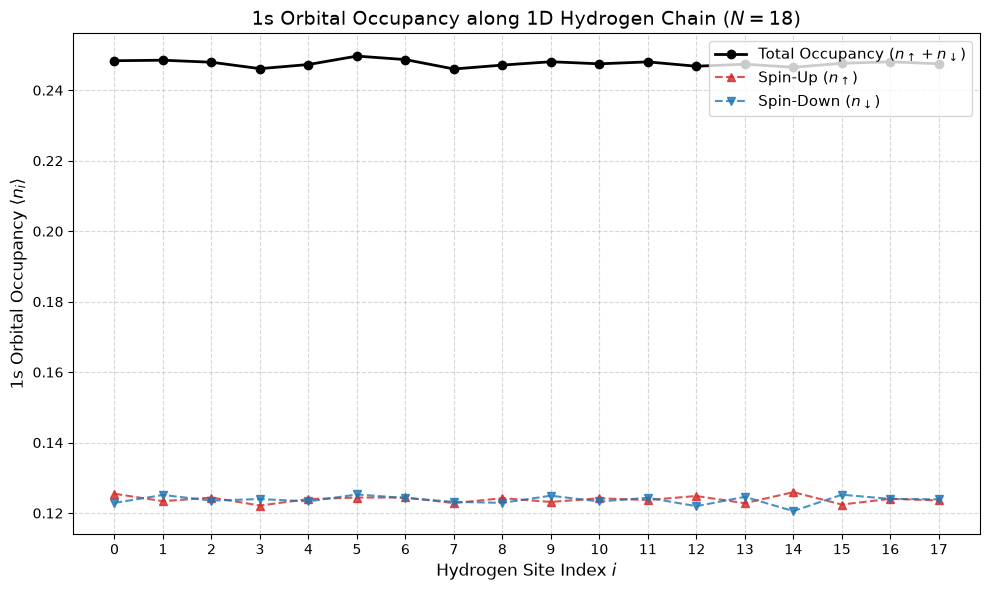

=== 1s Orbital Occupancies ===
Site |   Up   |  Down  |  Total 
-----------------------------------
  0  | 0.1255 | 0.1229 | 0.2484
  1  | 0.1234 | 0.1251 | 0.2485
  2  | 0.1244 | 0.1235 | 0.2480
  3  | 0.1221 | 0.1240 | 0.2461
  4  | 0.1240 | 0.1233 | 0.2473
  5  | 0.1244 | 0.1253 | 0.2497
  6  | 0.1244 | 0.1243 | 0.2487
  7  | 0.1228 | 0.1232 | 0.2460
  8  | 0.1242 | 0.1229 | 0.2471
  9  | 0.1232 | 0.1249 | 0.2481
 10  | 0.1242 | 0.1233 | 0.2475
 11  | 0.1237 | 0.1243 | 0.2480
 12  | 0.1248 | 0.1220 | 0.2468
 13  | 0.1228 | 0.1246 | 0.2474
 14  | 0.1259 | 0.1206 | 0.2465
 15  | 0.1224 | 0.1252 | 0.2476
 16  | 0.1240 | 0.1240 | 0.2481
 17  | 0.1236 | 0.1239 | 0.2475


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load your digest
path = "runs/h_chain_18_rdm_eval_all_gaussian_init" 
digest_file = os.path.join(path, "evaluation_digest.npz")
digest = dict(np.load(digest_file))

# Extract the 1RDM arrays
# Standard JaQMC output keys for the 1-particle RDM
g1_u = digest['gamma1_up_ii']
g1_d = digest['gamma1_down_ii']

n_sites = 18

# =====================================================================
# 1. Calculate Occupancies
# =====================================================================
# The occupancy of the i-th orbital is the diagonal element [i, i] of the 1RDM
# Extract the diagonals and take the real part (imaginary part is QMC noise)
if g1_u.ndim == 1:
    occ_up = g1_u.real
    occ_down = g1_d.real
else:
    occ_up = np.diag(g1_u).real
    occ_down = np.diag(g1_d).real

# Total 1s occupancy per site is the sum of up and down spins
occ_total = occ_up + occ_down

# =====================================================================
# 2. Plotting
# =====================================================================
sites = np.arange(n_sites)

plt.figure(figsize=(10, 6))

# Plot total occupancy
plt.plot(sites, occ_total, marker='o', linestyle='-', color='black', linewidth=2, 
         label=r'Total Occupancy ($n_{\uparrow} + n_{\downarrow}$)')

# Plot individual spin channels to check for spin polarization symmetry
plt.plot(sites, occ_up, marker='^', linestyle='--', color='tab:red', alpha=0.8, 
         label=r'Spin-Up ($n_{\uparrow}$)')
plt.plot(sites, occ_down, marker='v', linestyle='--', color='tab:blue', alpha=0.8, 
         label=r'Spin-Down ($n_{\downarrow}$)')

# Draw a horizontal line at 1.0 (ideal half-filling reference)
# plt.axhline(1.0, color='gray', linewidth=1, linestyle=':', label='Ideal Half-Filling (1.0)')

plt.xlabel(r"Hydrogen Site Index $i$", fontsize=12)
plt.ylabel(r"1s Orbital Occupancy $\langle n_i \rangle$", fontsize=12)
plt.title(r"1s Orbital Occupancy along 1D Hydrogen Chain ($N=18$)", fontsize=14)
plt.xticks(sites)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# =====================================================================
# 3. Printing Summary Table
# =====================================================================
print("=== 1s Orbital Occupancies ===")
print("Site |   Up   |  Down  |  Total ")
print("-" * 35)
for i in range(n_sites):
    print(f" {i:2d}  | {occ_up[i]:.4f} | {occ_down[i]:.4f} | {occ_total[i]:.4f}")

In [2]:
g1_u

array([0.12547916+1.0934892e-05j, 0.12337963+6.5209438e-06j,
       0.12441191+2.2611657e-06j, 0.1221433 -4.4064612e-07j,
       0.12398014-8.0701540e-07j, 0.12440759-2.3515574e-06j,
       0.12443304+3.4668344e-06j, 0.12284253+1.4233699e-07j,
       0.12422868+8.0723557e-06j, 0.12315983+8.2132028e-06j,
       0.12420619+2.3514438e-06j, 0.12370647-8.0646703e-07j,
       0.12484899+7.8089943e-06j, 0.12279823-6.6293815e-06j,
       0.12594566-4.6704140e-06j, 0.1224286 +1.3887869e-06j,
       0.12404503-4.5110964e-06j, 0.12360314-8.1275357e-06j],
      dtype=complex64)

In [11]:
print("g1_u shape:", g1_u.shape)
print("g1_d shape:", g1_d.shape)

# Load Ni_sq from the digest
Ni_sq = digest["Ni_sq"]

print("\nNi_sq:")
print(Ni_sq)

print("\nmean(Ni_sq) =", np.mean(Ni_sq))
print("sum(Ni_sq)  =", np.sum(Ni_sq))

print("\n1 / number of orbitals =", 1 / len(Ni_sq))

print("\nTrace up   =", np.sum(g1_u.real))
print("Trace down =", np.sum(g1_d.real))
print("Trace total =", np.sum(g1_u.real) + np.sum(g1_d.real))

print("18 * Ni_sq:")
print(18 * Ni_sq)

print("\n4 * Ni_sq:")
print(4 * Ni_sq)


print("Per-site total occupancy:")
print(np.mean(occ_total))

print("\nExpected at half filling:")
print(1.0)

print("\nRatio measured/expected:")
print(np.mean(occ_total) / 1.0)

print("\nCorrection factor:")
print(1.0 / np.mean(occ_total))

print("=== RDM TRACE CHECK ===")

trace_up = np.sum(g1_u.real)
trace_down = np.sum(g1_d.real)

print(f"Trace up   = {trace_up:.6f}")
print(f"Trace down = {trace_down:.6f}")
print(f"Trace total = {trace_up + trace_down:.6f}")

print("\n=== OCCUPANCY ===")

print(f"Mean up occupancy   = {np.mean(occ_up):.6f}")
print(f"Mean down occupancy = {np.mean(occ_down):.6f}")
print(f"Mean total occupancy = {np.mean(occ_total):.6f}")

print("\n=== EXPECTED ===")

print("Expected N_up   = 9")
print("Expected N_down = 9")
print("Expected total  = 18")
print("Expected mean total site occupancy = 1")

print("\n=== FACTOR ===")

print(f"Up correction factor   = {9 / trace_up:.6f}")
print(f"Down correction factor = {9 / trace_down:.6f}")
print(f"Total correction factor = {18 / (trace_up + trace_down):.6f}")

Ni_sq = digest["Ni_sq"]

print("\n=== Ni_sq ===")
print("shape:", Ni_sq.shape)
print("first values:", Ni_sq[:10])
print("mean:", np.mean(Ni_sq))
print("sum:", np.sum(Ni_sq))



g1_u shape: (18,)
g1_d shape: (18,)

Ni_sq:
[0.05597012 0.05616512 0.05632925 0.05615197 0.05567303 0.05510836
 0.05503983 0.0554242  0.05548875 0.05506433 0.05544656 0.05554748
 0.05570032 0.05513423 0.05483376 0.05524979 0.05572781 0.05594503]

mean(Ni_sq) = 0.055555552
sum(Ni_sq)  = 0.99999994

1 / number of orbitals = 0.05555555555555555

Trace up   = 2.2300482
Trace down = 2.2273762
Trace total = 4.457424
18 * Ni_sq:
[1.0074623  1.0109721  1.0139266  1.0107354  1.0021145  0.9919505
 0.9907169  0.9976356  0.9987974  0.99115795 0.9980381  0.9998546
 1.0026058  0.9924162  0.98700774 0.99449617 1.0031005  1.0070106 ]

4 * Ni_sq:
[0.2238805  0.22466049 0.22531702 0.22460787 0.22269213 0.22043344
 0.2201593  0.2216968  0.22195499 0.22025733 0.22178625 0.22218992
 0.2228013  0.22053693 0.21933505 0.22099915 0.22291122 0.22378013]
Per-site total occupancy:
0.24763468

Expected at half filling:
1.0

Ratio measured/expected:
0.24763468

Correction factor:
4.0382066
=== RDM TRACE CHECK ===
T

In [4]:
from pyscf import lo
from pyscf.pbc.tools.pbc import super_cell
import numpy as np

# Build the same primitive cell as your RDM estimator
from pyscf.pbc import gto

cell = gto.Cell()
cell.atom = [
    ["H", [0.0, 0.0, 0.0]],
    ["H", [2.8, 0.0, 0.0]],
]
cell.a = np.array([
    [5.6, 0.0, 0.0],
    [0.0, 100.0, 0.0],
    [0.0, 0.0, 100.0],
])
cell.basis = {"H": "cc-pvdz"}
cell.unit = "B"
cell.charge = 0
cell.spin = 0
cell.build()

supcell = super_cell(cell, [9, 1, 1], wrap_around=False)

labels = [x.strip() for x in supcell.ao_labels()]

for i, label in enumerate(labels):
    if " H 1s" in label:
        print(i, label)

print("\nTotal AOs:", len(labels))
print("Number of H 1s AOs:", sum(" H 1s" in x for x in labels))

0 0 H 1s
5 1 H 1s
10 2 H 1s
15 3 H 1s
20 4 H 1s
25 5 H 1s
30 6 H 1s
35 7 H 1s
40 8 H 1s
45 9 H 1s
50 10 H 1s
55 11 H 1s
60 12 H 1s
65 13 H 1s
70 14 H 1s
75 15 H 1s
80 16 H 1s
85 17 H 1s

Total AOs: 90
Number of H 1s AOs: 18


In [7]:
mo_coeff = lo.orth_ao(supcell, "meta-lowdin")

print("mo_coeff shape:", mo_coeff.shape)

h1s_indices = [
    i for i, label in enumerate(labels)
    if " H 1s" in label
]

print("H 1s indices:")
print(h1s_indices)

mo_coeff shape: (90, 90)
H 1s indices:
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85]


In [14]:
for i in h1s_indices[:5]:
    print(f"\n{labels[i]}")
    print("largest coefficient magnitude:",
          np.max(np.abs(mo_coeff[:, i])))
    print("norm of coefficient vector:",
          np.linalg.norm(mo_coeff[:, i]))


0 H 1s
largest coefficient magnitude: 0.7445026419352287
norm of coefficient vector: 0.8996900937606063

1 H 1s
largest coefficient magnitude: 0.7445026419352289
norm of coefficient vector: 0.8996900937606066

2 H 1s
largest coefficient magnitude: 0.7445026419352289
norm of coefficient vector: 0.8996900937606065

3 H 1s
largest coefficient magnitude: 0.7445026419352285
norm of coefficient vector: 0.899690093760606

4 H 1s
largest coefficient magnitude: 0.7445026419352283
norm of coefficient vector: 0.8996900937606059


In [9]:
h1s_set = set(h1s_indices)

for i in h1s_indices[:5]:
    weight_h1s = np.sum(np.abs(mo_coeff[list(h1s_set), i])**2)
    print(labels[i], "H1s coefficient weight =", weight_h1s)

0 H 1s H1s coefficient weight = 0.5921107639845736
1 H 1s H1s coefficient weight = 0.5921107639845741
2 H 1s H1s coefficient weight = 0.5921107639845739
3 H 1s H1s coefficient weight = 0.5921107639845732
4 H 1s H1s coefficient weight = 0.5921107639845731


In [10]:
from pyscf import lo
import numpy as np

print("--- Running Pipek-Mezey Localization ---")
# Feed the previously calculated meta-Lowdin mo_coeff as the starting point
pm = lo.PipekMezey(supcell, mo_coeff)
mo_coeff_pm = pm.kernel()

for i in h1s_indices[:5]:
    weight_h1s_pm = np.sum(np.abs(mo_coeff_pm[list(h1s_set), i])**2)
    print(f"{labels[i]} PM H1s coefficient weight =", weight_h1s_pm)

--- Running Pipek-Mezey Localization ---
0 H 1s PM H1s coefficient weight = 0.5901827502677792
1 H 1s PM H1s coefficient weight = 0.5913231169728087
2 H 1s PM H1s coefficient weight = 0.5931950487490927
3 H 1s PM H1s coefficient weight = 0.5940324430916596
4 H 1s PM H1s coefficient weight = 0.5936306845083852
